# Amazon Computers Co-purchase Graph Analysis


## 0. Setup


## Dataset 

Amazon Computers：
- nodes代表商品。
- edges代表兩個商品經常被一起購買。
- node features是商品評論的 bag-of-words 編碼。
- labels由商品類別決定。

對應如下：
1. nodes.csv：包含 node_id、數值特徵欄位、label。
2. edges.csv：包含 source 與 target，表示圖中的連結。
3. classes.csv：將 class_id 對應到 class_name。



In [ ]:
import os
from pathlib import Path

work_dir = Path('.').resolve()

os.chdir(work_dir)

print(f"Working directory: {work_dir}")
for name in ('nodes.csv', 'edges.csv', 'classes.csv'):
    print(f"{name}: {work_dir / name}")


Working directory: /home/russell512/Dataset
nodes.csv: /home/russell512/Dataset/nodes.csv
edges.csv: /home/russell512/Dataset/edges.csv
classes.csv: /home/russell512/Dataset/classes.csv


## 1. Utility Functions (`utils_graph.py`)


In [ ]:
import json
import math
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

class DatasetBundle:

    # 簡單包資料，後面直接取用
    def __init__(self, node_ids, x, y, edges_undirected, class_names):
        self.node_ids = node_ids
        self.x = x
        self.y = y
        self.edges_undirected = edges_undirected
        self.class_names = class_names

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def choose_device(preference='auto', min_free_gb=1.5):
    if preference == 'cpu':
        return torch.device('cpu')
    if preference == 'cuda':
        return torch.device('cuda')
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_dataset(dataset_dir):
    dataset_path = Path(dataset_dir)
    nodes_df = pd.read_csv(dataset_path / 'nodes.csv') #有每個node的766維度的features跟label，共有13752個node，node_id從0到137501，label是0到8的類別
    edges_df = pd.read_csv(dataset_path / 'edges.csv') #edges的source跟target都是node_id，存的方式是edge list
    classes_df = pd.read_csv(dataset_path / 'classes.csv') #共有9種class，class_id從0到8，class_name是類別名稱

    #處理nodes_df
    nodes_df = nodes_df.sort_values('node_id').reset_index(drop=True) #保險重排一下id (雖然應該不需要)，確保node_id從0到n-1的順序，這樣後續轉成tensor就不會亂掉
    node_ids = nodes_df['node_id'].to_numpy(dtype=np.int64)
    node_id_to_idx = {nid: idx for idx, nid in enumerate(node_ids.tolist())} #node_id從0到137501，但我怕中間不連續，所以這裡建立一個把node_id轉成從0到n-1的index，方便後續處理
    # node_id_to_idx是個dict，key是node_id，value是從0到n-1的index，這樣就算node_id不連續也沒關係了
    # 例如 : node_id_to_idx = {0: 0, 507: 1, 6551: 2, ...}
    feature_cols = [c for c in nodes_df.columns if c not in ('node_id', 'label')] #['node_id', 'f1', 'f2', 'f3', ..., 'f766', 'label'] 一個node有766維的features，還有一個label，先把feature_cols找出來，去掉node_id跟label
    # feature_cols = ['f1', 'f2', ..., 'f766']
    # x_np 就是最後要被送入模型的Feature Matrix
    # y_np 就是最後要被送入模型的labels
    x_np = nodes_df[feature_cols].to_numpy(dtype=np.float32).copy() #轉成numpy array，shape是(13752, 766)，每一行是node的features，這就是Feature Matrix，這樣x_np就去掉了node_id跟label，只剩features，變成一個純粹的數值矩陣
    y_np = nodes_df['label'].to_numpy(dtype=np.int64).copy() #轉成numpy array，shape是(13752,)，每一行是node的label
    
    #處理edges_df
    # 把 dataframe 裡的 source 跟 target 抓出來，轉成 numpy array，shape會是 (E, 2)
    edges_raw = edges_df[['source', 'target']].to_numpy(dtype=np.int64)
    seen_set = set() # 創一個 set 來記錄看過的邊，避免重複
    edge_tmp = [] # 拿來裝處理好的邊
    
    # 這邊先把 edge 去重，並確保不會有 self-loop 先混在裡面
    for u, v in np.asarray([(node_id_to_idx[s], node_id_to_idx[t]) for s, t in edges_raw.tolist()], dtype=np.int64).tolist():
        # u跟v是轉換後的idx (從0到N-1連續的)，如果自己存自己 (u==v)，就先跳過，之後會統一加
        if u == v:
            continue
        # 把比較小的當前點，比較大的當後點，這樣去重才準確 (因為現在把它當無向圖處理，(u,v) 應該等同於 (v,u))
        a, b = (u, v) if u < v else (v, u)
        key = (int(a), int(b))
        
        # 如果這個無向邊已經加過了，就跳過
        if key in seen_set:
            continue
            
        seen_set.add(key)
        edge_tmp.append(key)
        
    # 把去重完的 edge 轉回 numpy，這就是乾淨的無向邊 edge list，shape是 (E_new, 2)
    edges_undirected = np.asarray(edge_tmp, dtype=np.int64)
    
    # 處理 class_names
    # 轉成 dict 方便對照: {0: 'TV Shows', 1: 'Government and Politics', ...}
    class_names = {int(row.class_id): str(row.class_name) for row in classes_df.itertuples(index=False)}
    
    # 最後包裝成 DatasetBundle 丟出去，順便把 numpy array 轉成 PyTorch 的 Tensor
    return DatasetBundle(node_ids=node_ids, x=torch.from_numpy(x_np), y=torch.from_numpy(y_np), edges_undirected=edges_undirected, class_names=class_names)

def build_directed_edge_index(edges_undirected, num_nodes, add_self_loops=True):
    # 先把原本的 [u, v] 反向變成 [v, u]，這樣模型在跑 Message Passing 時，訊息才能暢通無阻（雙向流動）
    rev = edges_undirected[:, [1, 0]]
    # 把它們接在一起，現在有原本的邊跟反向的邊了
    directed = np.concatenate([edges_undirected, rev], axis=0)
    
    # 決定要不要自己連自己的邊 (Self-loop)
    if add_self_loops:
        # 做出 [0, 1, 2, ..., N-1]
        loops = np.arange(num_nodes, dtype=np.int64)
        # 疊成 [[0,0], [1,1], [2,2]...] 點自己連自己
        loops = np.stack([loops, loops], axis=1)
        # 再把它接到所有的邊裡面
        directed = np.concatenate([directed, loops], axis=0)
        
    # 保險起見再 unique 一次，怕有重複的邊，確保乾淨
    directed_unique = np.unique(directed, axis=0)
    
    # PyG 規定的 edge_index 形狀要是 (2, Num_edges)，所以要轉置 (.T)，並且要是 long() 也就是 int64 型別
    edge_index = torch.from_numpy(directed_unique.T).long()
    return edge_index

def mask_from_indices(num_nodes, indices):
    mask = torch.zeros(num_nodes, dtype=torch.bool)
    mask[torch.from_numpy(indices)] = True
    return mask

def accuracy_from_logits(logits, labels):
    pred = logits.argmax(dim=-1)
    return float((pred == labels).float().mean().item())

def roc_auc_binary(y_true, y_score):
    y_true = y_true.astype(np.int64)
    y_score = y_score.astype(np.float64)
    n_p = int((y_true == 1).sum())
    n_n = int((y_true == 0).sum())
    if n_p == 0 or n_n == 0:
        return float('nan')
    order = np.argsort(y_score, kind='mergesort')
    sorted_scores = y_score[order]
    ranks = np.empty(len(y_score), dtype=np.float64)
    i = 0
    while i < len(order):
        j = i + 1
        while j < len(order) and sorted_scores[j] == sorted_scores[i]:
            j += 1
        avg_rank = 0.5 * (i + 1 + j)
        ranks[order[i:j]] = avg_rank
        i = j
    rank_sum_pos = ranks[y_true == 1].sum()
    auc = (rank_sum_pos - n_p * (n_p + 1) / 2.0) / (n_p * n_n)
    return float(auc)

def binary_metrics(y_true, y_prob, threshold):
    y_true = y_true.astype(np.int64)
    y_pred = (y_prob >= threshold).astype(np.int64)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2.0 * precision * recall / (precision + recall + 1e-12)
    acc = (tp + tn) / max(1, tp + tn + fp + fn)
    return {'precision': float(precision), 'recall': float(recall), 'f1': float(f1), 'accuracy': float(acc), 'tp': float(tp), 'fp': float(fp), 'tn': float(tn), 'fn': float(fn)}

def find_best_threshold_by_f1(y_true, y_prob, num_thresholds=401):
    best_threshold = 0.5
    best_metrics = binary_metrics(y_true, y_prob, best_threshold)
    for thr in np.linspace(0.0, 1.0, num_thresholds):
        m = binary_metrics(y_true, y_prob, float(thr))
        if m['f1'] > best_metrics['f1']:
            best_threshold = float(thr)
            best_metrics = m
    return (best_threshold, best_metrics)

def pca_project_2d(x):
    x_centered = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(x_centered, full_matrices=False)
    proj = x_centered @ vt[:2].T
    return proj

def plot_embedding(emb_2d, labels, out_path, title, class_names=None):
    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(labels)
    cmap = plt.get_cmap('tab10', len(unique_labels))
    for i, label in enumerate(unique_labels):
        mask = labels == label
        label_name = class_names.get(int(label), str(label)) if class_names else str(label)
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=8, alpha=0.7, label=label_name, color=cmap(i))
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(markerscale=2.0, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def save_json(data, out_path):
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

def build_undirected_edge_set(edges):
    out = set()
    for u, v in edges.tolist():
        a, b = (int(u), int(v)) if u < v else (int(v), int(u))
        if a != b:
            out.add((a, b))
    return out

def temporal_split_edges(edges_undirected_in_order, train_ratio, val_ratio, test_ratio):
    n = edges_undirected_in_order.shape[0]
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    train_pos = edges_undirected_in_order[:n_train]
    val_pos = edges_undirected_in_order[n_train:n_train + n_val]
    test_pos = edges_undirected_in_order[n_train + n_val:n_train + n_val + n_test]
    return (train_pos, val_pos, test_pos)

def sample_negative_edges(num_nodes, num_samples, positive_edge_set, rng, forbidden=None):
    chosen = set()
    if forbidden is None:
        forbidden = set()
    max_attempts = max(50000, num_samples * 25)
    attempts = 0
    while len(chosen) < num_samples and attempts < max_attempts:
        u = int(rng.integers(0, num_nodes))
        v = int(rng.integers(0, num_nodes))
        attempts += 1
        if u==v:
            continue
        a, b = (u, v) if u < v else (v, u)
        key = (a, b)
        if key in positive_edge_set or key in forbidden or key in chosen:
            continue
        chosen.add(key)
    if len(chosen) < num_samples:
        needed = num_samples - len(chosen)
        for u in range(num_nodes):
            if needed <= 0:
                break
            v = (u + 1) % num_nodes
            a, b = (u, v) if u < v else (v, u)
            key = (a, b)
            if key in positive_edge_set or key in forbidden or key in chosen or (a == b):
                continue
            chosen.add(key)
            needed -= 1
    if len(chosen) < num_samples:
        raise RuntimeError('Unable to sample enough negative edges')
    return np.asarray(list(chosen), dtype=np.int64)

def build_neighbor_sets(num_nodes, edges_undirected):
    neighbors = [set() for _ in range(num_nodes)]
    for u, v in edges_undirected.tolist():
        neighbors[int(u)].add(int(v))
        neighbors[int(v)].add(int(u))
    return neighbors

def sample_hard_negative_edges(num_nodes, num_samples, positive_edge_set, neighbors, rng, hard_fraction=0.5):
    hard_target = int(num_samples * hard_fraction)
    chosen = set()
    nodes_with_neighbors = [i for i in range(num_nodes) if neighbors[i]]
    attempts = 0
    max_attempts = max(100000, hard_target * 40)
    while len(chosen) < hard_target and attempts < max_attempts and nodes_with_neighbors:
        u = int(nodes_with_neighbors[int(rng.integers(0, len(nodes_with_neighbors)))])
        u_nei = list(neighbors[u])
        mid = int(u_nei[int(rng.integers(0, len(u_nei)))])
        second = neighbors[mid]
        if not second:
            attempts += 1
            continue
        v = int(list(second)[int(rng.integers(0, len(second)))])
        attempts += 1
        if u==v:
            continue
        a, b = (u, v) if u < v else (v, u)
        key = (a, b)
        if key in positive_edge_set or key in chosen:
            continue
        chosen.add(key)
    needed_random = num_samples - len(chosen)
    random_part = sample_negative_edges(num_nodes=num_nodes, num_samples=needed_random, positive_edge_set=positive_edge_set, rng=rng, forbidden=chosen)
    out = list(chosen)
    out.extend(map(tuple, random_part.tolist()))
    return np.asarray(out, dtype=np.int64)


## 2. Graph Models (`graph_models.py`)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SparseGATLayer(nn.Module):

    def __init__(self, in_dim, out_dim, heads=4, dropout=0.3, negative_slope=0.2, concat=True, edge_chunk_size=100000):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.heads = heads
        self.concat = concat
        self.dropout = dropout
        self.negative_slope = negative_slope
        self.edge_chunk_size = edge_chunk_size
        self.lin = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.att_src = nn.Parameter(torch.empty(heads, out_dim))
        self.att_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.bias = nn.Parameter(torch.zeros(heads * out_dim if concat else out_dim))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)
        nn.init.zeros_(self.bias)

    def _segment_softmax(self, scores, index, n_nodes):
        # scores的shape是 (E, heads)，也就是每一條邊在各個head上的Attention score
        # index的shape是 (E,)，記著每一條邊指向的終點node_id
        # n_nodes 是總共的節點數量
        h = scores.size(1) # 幾個head
        # 把index擴增到 (E, heads)，這樣才能跟scores做後續的gather/scatter操作
        index_exp = index.unsqueeze(-1).expand(-1, h)
        # 準備一個裝滿超級小數字的矩陣，shape是 (N, heads)
        # 因為接下來要做 softmax，怕 exponential 所以要先找最大值來扣
        max_per_node = torch.full((n_nodes, h), fill_value=-1000000000000000.0, device=scores.device, dtype=scores.dtype)
        # scatter_reduce 這裡就是把每一條邊的score 照著 index_exp 倒回對應的終點 node，挑出每個 node 最大的 score
        max_per_node.scatter_reduce_(0, index_exp, scores, reduce='amax', include_self=True)
        # 此時 max_per_node 就是每個節點收到的所有鄰居score裡面的最大值
        # 把每一條邊的score 減掉 指向的那個node的最大score (log-sum-exp trick 避免溢位)
        norm_scores = scores - max_per_node[index]
        exp_scores = torch.exp(norm_scores) # 這裡取exp比較安全了，算出來的是分子
        # 準備分母矩陣，一樣是 (N, heads)，全部塞零
        denom = torch.zeros((n_nodes, h), device=scores.device, dtype=scores.dtype)
        # scatter_add 就是把所有的 exp_scores，沿著終點 node_id 加總 
        denom.scatter_add_(0, index_exp, exp_scores)
        # 真正的 Softmax 也就是分子除以 (分母 + 一個微小的 eps 以免除以0)
        # 算出來的 alpha 就是最終的 Attention 權重啦，shape 保留為 (E, heads)
        alpha = exp_scores / (denom[index] + 1e-12)
        return alpha

    def forward(self, x, edge_index):
        n_nodes = x.size(0)
        src = edge_index[0]
        dst = edge_index[1]
        n_edges = src.size(0)
        x_proj = self.lin(x).view(n_nodes, self.heads, self.out_dim)
        att = torch.empty((n_edges, self.heads), device=x.device, dtype=x.dtype)
        for start in range(0, n_edges, self.edge_chunk_size):
            end = min(start + self.edge_chunk_size, n_edges)
            s = src[start:end]
            d = dst[start:end]
            x_src = x_proj[s]
            x_dst = x_proj[d]
            att_chunk = (x_src * self.att_src).sum(dim=-1) + (x_dst * self.att_dst).sum(dim=-1)
            att[start:end] = F.leaky_relu(att_chunk, negative_slope=self.negative_slope)
        alpha = self._segment_softmax(att, dst, n_nodes)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        out = torch.zeros((n_nodes, self.heads, self.out_dim), device=x.device, dtype=x.dtype)
        for start in range(0, n_edges, self.edge_chunk_size):
            end = min(start + self.edge_chunk_size, n_edges)
            s = src[start:end]
            d = dst[start:end]
            x_src = x_proj[s]
            alpha_chunk = alpha[start:end]
            messages = x_src * alpha_chunk.unsqueeze(-1)
            out.scatter_add_(0, d.view(-1, 1, 1).expand(-1, self.heads, self.out_dim), messages)
        if self.concat:
            out = out.reshape(n_nodes, self.heads * self.out_dim)
        else:
            out = out.mean(dim=1)
        out = out + self.bias
        return out

class GATNodeClassifier(nn.Module):

    def __init__(self, in_dim, hidden_dim, out_dim, heads, dropout):
        super().__init__()
        self.dropout = dropout
        self.gat1 = SparseGATLayer(in_dim=in_dim, out_dim=hidden_dim, heads=heads, dropout=dropout, concat=True)
        self.gat2 = SparseGATLayer(in_dim=hidden_dim * heads, out_dim=out_dim, heads=1, dropout=dropout, concat=False)

    def encode(self, x, edge_index):
        h = F.dropout(x, p=self.dropout, training=self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        return h

    def forward(self, x, edge_index):
        h = self.encode(x, edge_index)
        h = F.dropout(h, p=self.dropout, training=self.training)
        logits = self.gat2(h, edge_index)
        return logits

class GATEncoder(nn.Module):

    def __init__(self, in_dim, hidden_dim, out_dim, heads, dropout):
        super().__init__()
        self.dropout = dropout
        self.gat1 = SparseGATLayer(in_dim, hidden_dim, heads=heads, dropout=dropout, concat=True)
        self.gat2 = SparseGATLayer(hidden_dim * heads, out_dim, heads=1, dropout=dropout, concat=False)

    def forward(self, x, edge_index):
        h = F.dropout(x, p=self.dropout, training=self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        z = self.gat2(h, edge_index)
        return z

class BilinearDecoder(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.bilinear = nn.Bilinear(dim, dim, 1)

    def forward(self, z_src, z_dst):
        logits = self.bilinear(z_src, z_dst).squeeze(-1)
        return logits

class ResidualGATBlock(nn.Module):

    def __init__(self, in_dim, out_dim, heads, dropout):
        super().__init__()
        self.layer = SparseGATLayer(in_dim=in_dim, out_dim=out_dim, heads=heads, dropout=dropout, concat=True)
        self.norm = nn.LayerNorm(out_dim * heads)
        self.dropout = dropout
        self.res_proj = None
        if in_dim != out_dim * heads:
            self.res_proj = nn.Linear(in_dim, out_dim * heads)

    def forward(self, x, edge_index):
        h = self.layer(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        residual = self.res_proj(x) if self.res_proj is not None else x
        out = self.norm(h + residual)
        return out

class AdvancedGATEncoder(nn.Module):

    def __init__(self, in_dim, hidden_dim, out_dim, heads, dropout):
        super().__init__()
        self.block1 = ResidualGATBlock(in_dim=in_dim, out_dim=hidden_dim, heads=heads, dropout=dropout)
        self.block2 = ResidualGATBlock(in_dim=hidden_dim * heads, out_dim=hidden_dim, heads=heads, dropout=dropout)
        self.proj = nn.Linear(hidden_dim * heads, out_dim)

    def forward(self, x, edge_index):
        h = self.block1(x, edge_index)
        h = self.block2(h, edge_index)
        z = self.proj(h)
        return z

class EdgeMLPDecoder(nn.Module):

    def __init__(self, dim, hidden_dim=256, dropout=0.2):
        super().__init__()
        # 這裡會吃進四種特徵拼接 (u, v, u*v, |u-v|)
        # 所以進來的維度是原本 node feature dim 的 4 倍 (dim * 4)
        # 一連串的 MLP 把它降維再降維，最後壓縮到只剩 1 維 (預測這條邊存不存在的機率)
        self.mlp = nn.Sequential(nn.Linear(dim * 4, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1))

    def forward(self, z_src, z_dst):
        # z_src 跟 z_dst 都是 (E, D) 的 shape
        # 直接拿四種物理意義：起點特徵、終點特徵、相乘 (交集)、相減 (差異) 
        # cat完之後，h 的 shape 變成 (E, 4*D) 這就是最後要被送進mlp的特徵
        h = torch.cat([z_src, z_dst, z_src * z_dst, torch.abs(z_src - z_dst)], dim=-1)
        # 把 shape (E, 1) 的預測分數，暴力壓平(squeeze)變成 (E,)
        logits = self.mlp(h).squeeze(-1)
        return logits

class LinkPredictionModel(nn.Module):

    def __init__(self, encoder, decoder, edge_batch_size=100000):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        # 設定 edge_batch_size 就怕一口氣送幾百萬條邊會直接 OOM 記憶體壞掉
        self.edge_batch_size = edge_batch_size

    def forward(self, x, edge_index_graph, edge_pairs):
        # x 形狀 (N, 原本D)，過完 encoder 出來變 (N, 新的D)，這是全圖各點最新的 embedding (z)
        z = self.encoder(x, edge_index_graph)
        logits_chunks = []
        # 怕 OOM，所以把幾百萬條 edge_pairs 在長度上切塊 (chunk)
        for start in range(0, edge_pairs.size(0), self.edge_batch_size):
            end = min(start + self.edge_batch_size, edge_pairs.size(0))
            batch = edge_pairs[start:end] # 抓出這批的邊 (batch_size, 2)
            src = batch[:, 0] # 起點 ID，shape (batch_size,)
            dst = batch[:, 1] # 終點 ID，shape (batch_size,)
            # z[src] 就是去 lookup 這些點的 embedding，再拿來算出這批邊的分數
            logits_chunks.append(self.decoder(z[src], z[dst]))
        # 把 list 裡面一塊塊的 (batch_size,) 分數，沿著第 0 維接回去
        # 恢復成原本的總數量 (E, )
        logits = torch.cat(logits_chunks, dim=0)
        # 把 edge 打分 (logits) 跟 node embedding (z) 都吐出去 (這樣外面算 loss 比較方便)
        return (logits, z)


## Question 1


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np




def main():
    dataset_dir = "."
    output_dir = "results/q1"

    ensure_dir(output_dir)

    data = load_dataset(dataset_dir)
    node_n = data.x.size(0)
    feat_n = data.x.size(1)
    edge_n = int(data.edges_undirected.shape[0])

    deg_arr = np.zeros(node_n, dtype=np.int64)
    # 先算每個點的 degree
    for u,v in data.edges_undirected.tolist():
        deg_arr[int(u)] += 1
        deg_arr[int(v)] += 1

    dens=(2.0*edge_n)/(node_n*(node_n-1))
    isolated_nodes = int((deg_arr == 0).sum())

    x_arr = data.x.numpy()
    nonzero_count = (x_arr != 0).sum(axis=1)
    feat_density_each = nonzero_count / feat_n
    feat_density_all = float((x_arr != 0).sum() / x_arr.size)

    y_arr = data.y.numpy()
    uniq_lbl, lbl_counts = np.unique(y_arr, return_counts=True)
    lbl_dist = {
        int(lbl): {
            "count": int(cnt),
            "class_name": data.class_names.get(int(lbl), str(lbl)),
        }
        for lbl, cnt in zip(uniq_lbl.tolist(), lbl_counts.tolist())
    }

    # Union-Find set
    parent = np.arange(node_n, dtype=np.int64)
    rank = np.zeros(node_n, dtype=np.int64)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra = find(a)
        rb = find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    for u, v in data.edges_undirected.tolist():
        union(int(u), int(v))

    roots = np.array([find(i) for i in range(node_n)], dtype=np.int64)
    _, comp_counts = np.unique(roots, return_counts=True)
    comp_counts.sort()
    cc_sizes = comp_counts[::-1]

    stats = {
        "num_nodes": int(node_n),
        "num_edges": int(edge_n),
        "num_features": int(feat_n),
        "num_classes": int(len(uniq_lbl)),
        "graph_density": float(dens),
        "isolated_nodes": int(isolated_nodes),
        "degree": {
            "min": int(deg_arr.min()),
            "max": int(deg_arr.max()),
            "mean": float(deg_arr.mean()),
            "median": float(np.median(deg_arr)),
            "std": float(deg_arr.std()),
            "p95": float(np.percentile(deg_arr, 95)),
            "p99": float(np.percentile(deg_arr, 99)),
        },
        "feature_sparsity": {
            "global_density": feat_density_all,
            "global_sparsity": float(1.0 - feat_density_all),
            "nonzero_features_per_node_mean": float(nonzero_count.mean()),
            "nonzero_features_per_node_median": float(np.median(nonzero_count)),
            "nonzero_features_per_node_std": float(nonzero_count.std()),
        },
        "cc_sizes": {
            "count": int(cc_sizes.shape[0]),
            "largest_component_size": int(cc_sizes[0]),
            "smallest_component_size": int(cc_sizes[-1]),
            "top_10_sizes": [int(v) for v in cc_sizes[:10].tolist()],
        },
        "lbl_dist": lbl_dist,
    }

    json_path = str(Path(output_dir) / "q1_stats.json")
    save_json(stats, json_path)

    plt.figure(figsize=(10, 6))
    plt.hist(deg_arr, bins=60, color="#1f77b4", alpha=0.85)
    plt.title("Degree Distribution")
    plt.xlabel("Node degree")
    plt.ylabel("Node count")
    plt.tight_layout()
    plt.savefig(Path(output_dir) / "degree_distribution.png", dpi=200)
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.hist(feat_density_each, bins=60, color="#ff7f0e", alpha=0.85)
    plt.title("Feature Density per Node")
    plt.xlabel("Non-zero feature ratio")
    plt.ylabel("Node count")
    plt.tight_layout()
    plt.savefig(Path(output_dir) / "feature_density_distribution.png", dpi=200)
    plt.close()

    plt.figure(figsize=(11, 5))
    x_ticks = [data.class_names.get(int(lbl), str(lbl)) for lbl in uniq_lbl]
    plt.bar(x_ticks, lbl_counts, color="#2ca02c", alpha=0.85)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Node count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(Path(output_dir) / "class_distribution.png", dpi=200)
    plt.close()

    print("Q1 completed")
    print(f"Nodes: {node_n}, Edges: {edge_n}, Features: {feat_n}")
    print(f"Average degree: {deg_arr.mean():.4f}, Density: {dens:.8f}")
    print(f"Statistics saved to: {json_path}")





# Run the main function for Q1
main()



Q1 completed
Nodes: 13752, Edges: 245861, Features: 767
Average degree: 35.7564, Density: 0.00260028
Statistics saved to: results/q1/q1_stats.json


---------- Q1: Graph Statistics Visualizations ----------


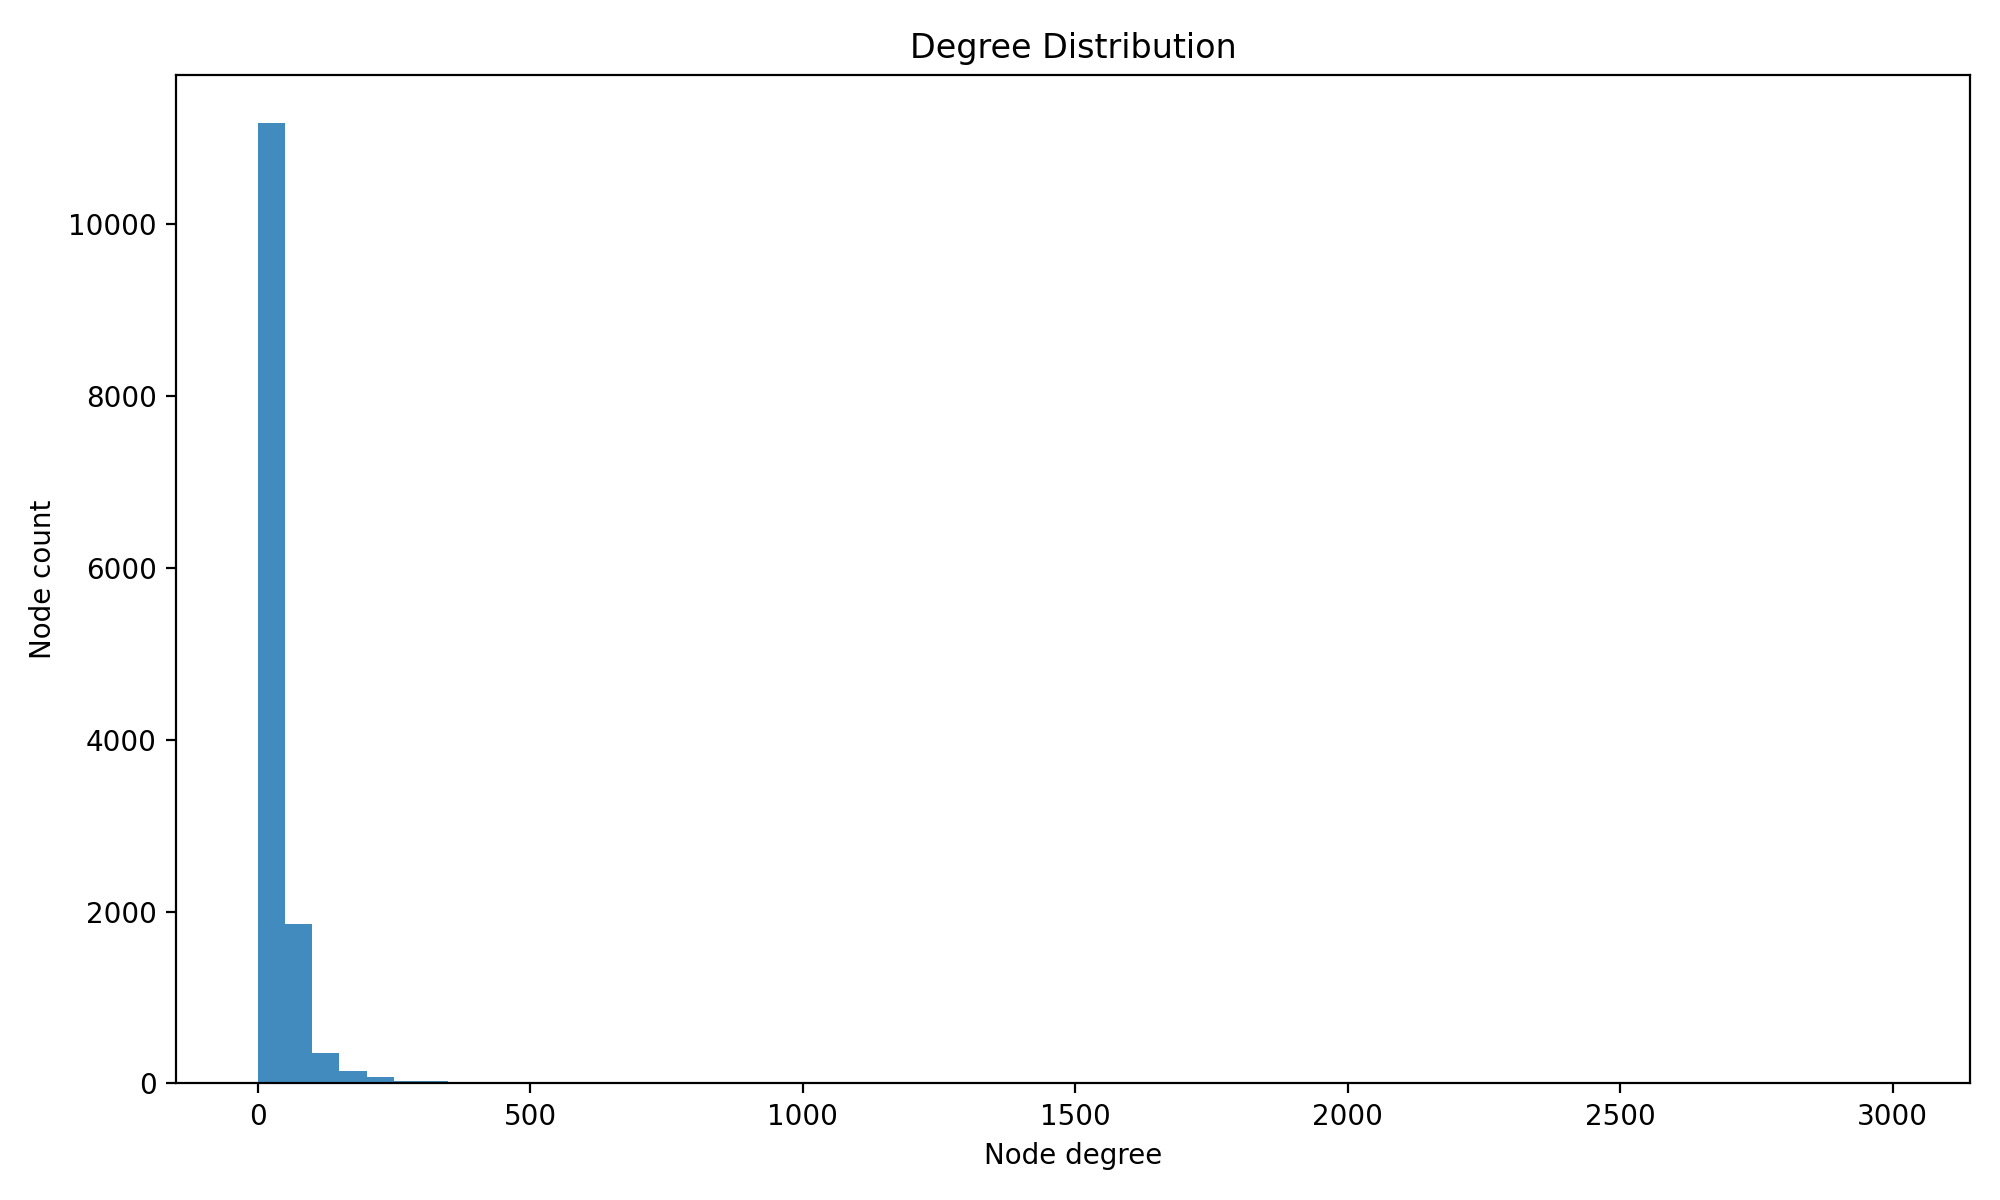

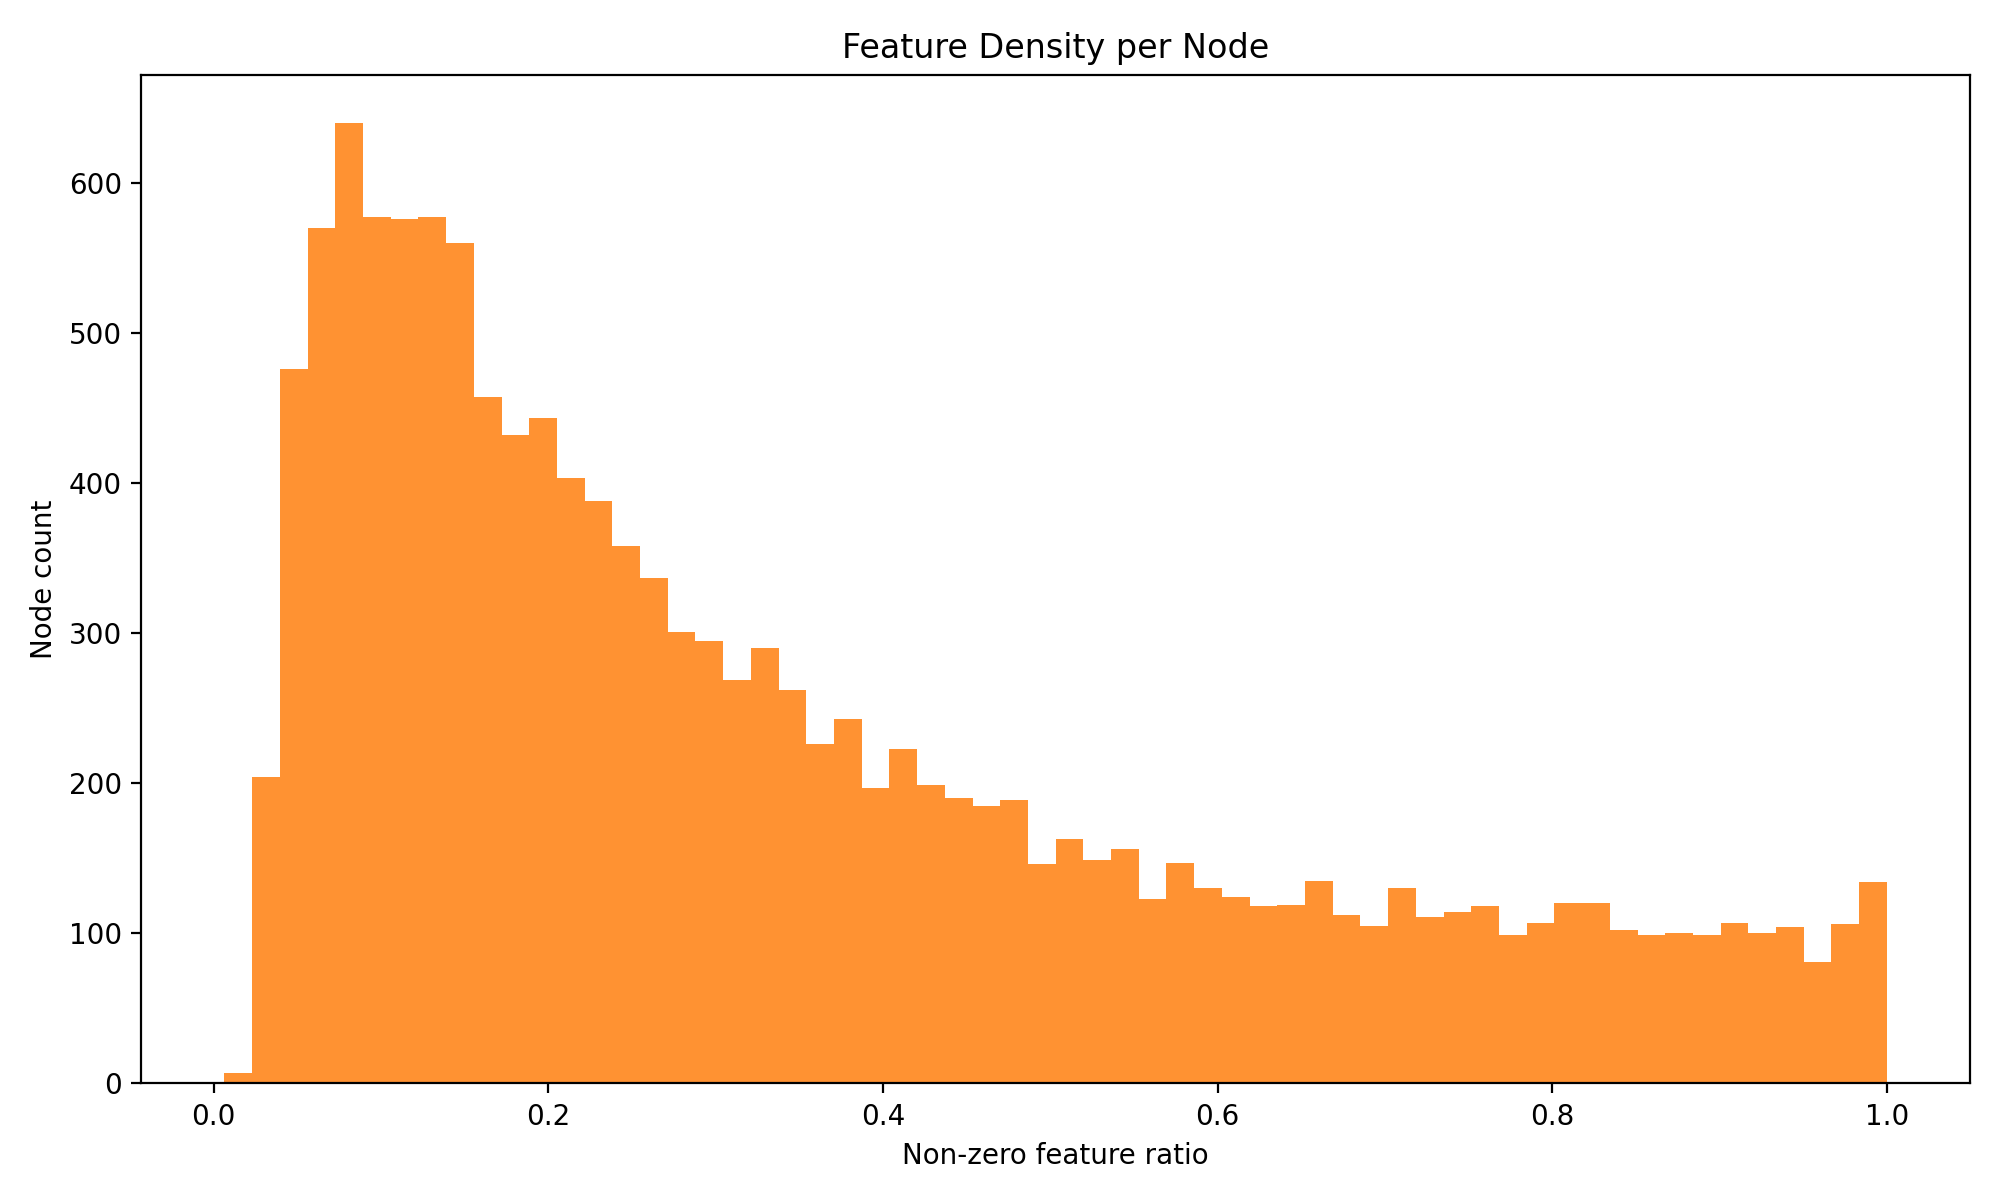

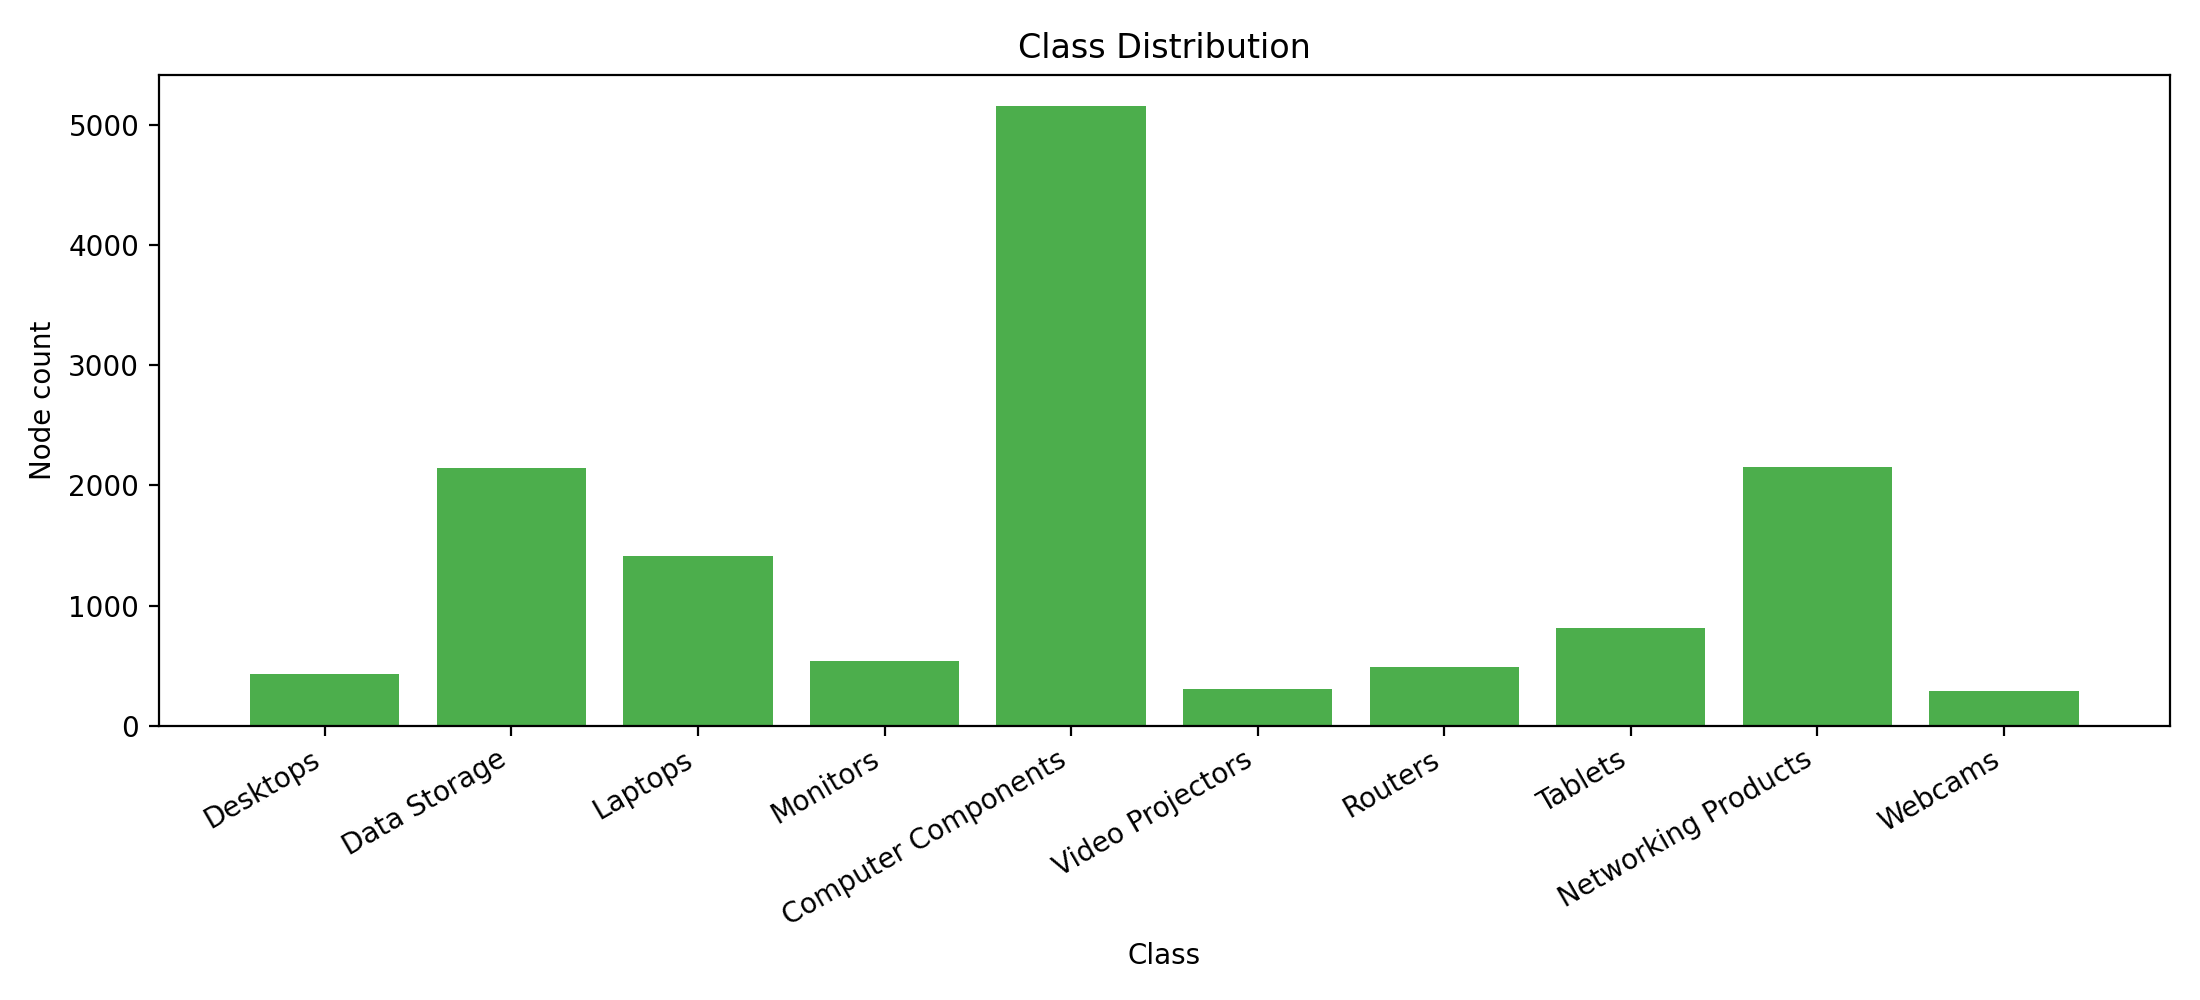

In [5]:
from IPython.display import Image, display

print("---------- Q1: Graph Statistics Visualizations ----------")
display(Image(filename='results/q1/degree_distribution.png'))
display(Image(filename='results/q1/feature_density_distribution.png'))
display(Image(filename='results/q1/class_distribution.png'))


### Q1 

-  Amazon Computers co-purchase network
- 節點與特徵統計：nodes = 13,752，features = 767。
- 邊與密度：undirected edges = 245,861，graph density = 0.002600。

密度僅有 0.26%。因此必須使用 Edge List 來儲存，這也是後續 Link Prediction 任務中，負樣本空間極度龐大的原因。


## Question 2


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F





def main():
    dataset_dir = "."
    output_dir = "results/q2"
    seed = 42
    epochs = 300
    patience = 40
    lr = 0.005
    weight_decay = 5e-4
    dropout = 0.5
    hidden_dim = 32
    heads = 8
    train_ratio = 0.35
    val_ratio = 0.25
    test_ratio = 0.40
    device_pref = "auto"

    ensure_dir(output_dir)
    set_seed(seed)

    device = choose_device(device_pref)
    data = load_dataset(dataset_dir)

    x = data.x.to(device)
    y = data.y.to(device)
    num_nodes = x.size(0)
    num_classes = int(y.max().item()) + 1

    edge_index = build_directed_edge_index(data.edges_undirected, num_nodes, add_self_loops=True).to(device)

    y_np = data.y.numpy()
    rng_np = np.random.default_rng(seed)
    tr_idx = []
    va_idx = []
    te_idx = []
    cls_all = np.unique(y_np)
    for c in cls_all:
        c_idx = np.where(y_np == c)[0]
        rng_np.shuffle(c_idx)
        n = len(c_idx)
        n_tr = int(round(n * train_ratio))
        n_va = int(round(n * val_ratio))
        if n_tr + n_va > n:
            n_va = max(0, n - n_tr)
        n_te = n - n_tr - n_va
        tr_idx.extend(c_idx[:n_tr].tolist())
        va_idx.extend(c_idx[n_tr:n_tr + n_va].tolist())
        te_idx.extend(c_idx[n_tr + n_va:n_tr + n_va + n_te].tolist())
    tr_idx = np.asarray(tr_idx, dtype=np.int64)
    va_idx = np.asarray(va_idx, dtype=np.int64)
    te_idx = np.asarray(te_idx, dtype=np.int64)
    rng_np.shuffle(tr_idx)
    rng_np.shuffle(va_idx)
    rng_np.shuffle(te_idx)

    train_mask = mask_from_indices(num_nodes, tr_idx).to(device)
    val_mask = mask_from_indices(num_nodes, va_idx).to(device)
    test_mask = mask_from_indices(num_nodes, te_idx).to(device)

    model = GATNodeClassifier(
        in_dim=x.size(1),
        hidden_dim=hidden_dim,
        out_dim=num_classes,
        heads=heads,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(),lr=lr, weight_decay=weight_decay)

    # 先看訓練前 embedding
    model.eval()
    with torch.no_grad():
        emb_b = model.encode(x, edge_index).detach().cpu().numpy()
    emb_b2 = pca_project_2d(emb_b)
    plot_embedding(
        emb_2d=emb_b2,
        labels=y_np,
        out_path=str(Path(output_dir) / "embedding_before_training.png"),
        title="Node Embedding Before Training (PCA)",
        class_names=data.class_names,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(x, edge_index)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        train_acc = accuracy_from_logits(logits[train_mask], y[train_mask])
        val_metrics = evaluate(model, x, y, edge_index, val_mask)

        history["train_loss"].append(float(loss.item()))
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(float(train_acc))
        history["val_acc"].append(val_metrics["acc"])

        improved = val_metrics["acc"] > best_val_acc
        if improved:
            best_val_acc = val_metrics["acc"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={loss.item():.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f}"
        )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}, best epoch {best_epoch}")
            break

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        logits = model(x, edge_index)
        test_loss = F.cross_entropy(logits[test_mask], y[test_mask]).item()
        test_acc = accuracy_from_logits(logits[test_mask], y[test_mask])

        pred = logits.argmax(dim=-1)
        emb_a = model.encode(x, edge_index).detach().cpu().numpy()

    emb_a2 = pca_project_2d(emb_a)
    plot_embedding(
        emb_2d=emb_a2,
        labels=y_np,
        out_path=str(Path(output_dir) / "embedding_after_training.png"),
        title="Node Embedding After Training (PCA)",
        class_names=data.class_names,
    )

    epochs_arr = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].plot(epochs_arr, history["train_loss"], label="train_loss")
    ax[0].plot(epochs_arr, history["val_loss"], label="val_loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Training / Validation Loss")
    ax[0].legend()
    ax[1].plot(epochs_arr, history["train_acc"], label="train_acc")
    ax[1].plot(epochs_arr, history["val_acc"], label="val_acc")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_title("Training / Validation Accuracy")
    ax[1].legend()
    fig.tight_layout()
    fig.savefig(str(Path(output_dir) / "training_curves.png"), dpi=200)
    plt.close(fig)

    per_cls = {}
    y_cpu_arr = y.detach().cpu().numpy()
    pred_cpu_arr = pred.detach().cpu().numpy()
    test_mask_np = test_mask.detach().cpu().numpy().astype(bool)
    for c in np.unique(y_cpu_arr[test_mask_np]):
        class_mask = test_mask_np & (y_cpu_arr == c)
        count = int(class_mask.sum())
        if count == 0:
            continue
        acc_c = float((pred_cpu_arr[class_mask] == y_cpu_arr[class_mask]).mean())
        per_cls[int(c)] = {
            "accuracy": acc_c,
            "class_name": data.class_names.get(int(c), str(int(c))),
            "count": count,
        }

    results = {
        "seed": seed,
        "device": str(device),
        "split": {
            "train_ratio": train_ratio,
            "val_ratio": val_ratio,
            "test_ratio": test_ratio,
            "train_count": int(train_mask.sum().item()),
            "val_count": int(val_mask.sum().item()),
            "test_count": int(test_mask.sum().item()),
        },
        "hyperparameters": {
            "epochs": epochs,
            "patience": patience,
            "lr": lr,
            "weight_decay": weight_decay,
            "dropout": dropout,
            "hidden_dim": hidden_dim,
            "heads": heads,
        },
        "best_epoch": int(best_epoch),
        "best_val_acc": float(best_val_acc),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "per_class": per_cls,
    }

    save_json(results, str(Path(output_dir) / "q2_metrics.json"))
    torch.save(best_state, str(Path(output_dir) / "best_q2_model.pt"))

    print("Q2 completed")
    print(f"Best val acc: {best_val_acc:.4f} (epoch {best_epoch})")
    print(f"Test acc: {test_acc:.4f}, Test loss: {test_loss:.4f}")
    print(f"Artifacts saved in: {output_dir}")





# Run the main function for Q2
main()



Epoch 001 | train_loss=2.9978 train_acc=0.1045 | val_loss=9.6231 val_acc=0.3750
Epoch 002 | train_loss=9.2259 train_acc=0.3695 | val_loss=5.1660 val_acc=0.1613
Epoch 003 | train_loss=4.9962 train_acc=0.1789 | val_loss=3.2840 val_acc=0.3564


Epoch 004 | train_loss=3.2304 train_acc=0.3245 | val_loss=2.8132 val_acc=0.4221
Epoch 005 | train_loss=2.7810 train_acc=0.3631 | val_loss=2.4003 val_acc=0.4125
Epoch 006 | train_loss=2.4671 train_acc=0.3581 | val_loss=2.0470 val_acc=0.3698


Epoch 007 | train_loss=2.2020 train_acc=0.3519 | val_loss=1.8230 val_acc=0.3721
Epoch 008 | train_loss=2.1430 train_acc=0.3982 | val_loss=1.7716 val_acc=0.4480
Epoch 009 | train_loss=2.1192 train_acc=0.4179 | val_loss=1.7636 val_acc=0.4715


Epoch 010 | train_loss=2.0462 train_acc=0.4314 | val_loss=1.7323 val_acc=0.4523
Epoch 011 | train_loss=1.9319 train_acc=0.4373 | val_loss=1.6927 val_acc=0.4055
Epoch 012 | train_loss=1.8737 train_acc=0.4221 | val_loss=1.6540 val_acc=0.3881


Epoch 013 | train_loss=1.7900 train_acc=0.4329 | val_loss=1.6176 val_acc=0.4276
Epoch 014 | train_loss=1.7672 train_acc=0.4489 | val_loss=1.5830 val_acc=0.5020
Epoch 015 | train_loss=1.7209 train_acc=0.4882 | val_loss=1.5534 val_acc=0.5369


...

Epoch 286 | train_loss=0.3506 train_acc=0.8961 | val_loss=0.2846 val_acc=0.9116
Epoch 287 | train_loss=0.3272 train_acc=0.9071 | val_loss=0.2855 val_acc=0.9087
Epoch 288 | train_loss=0.3571 train_acc=0.8976 | val_loss=0.2841 val_acc=0.9096


Epoch 289 | train_loss=0.3367 train_acc=0.9001 | val_loss=0.2809 val_acc=0.9137
Epoch 290 | train_loss=0.3370 train_acc=0.9022 | val_loss=0.2808 val_acc=0.9157
Epoch 291 | train_loss=0.3470 train_acc=0.8980 | val_loss=0.2811 val_acc=0.9157


Epoch 292 | train_loss=0.3423 train_acc=0.9024 | val_loss=0.2831 val_acc=0.9134
Epoch 293 | train_loss=0.3479 train_acc=0.8995 | val_loss=0.2823 val_acc=0.9134
Epoch 294 | train_loss=0.3347 train_acc=0.9013 | val_loss=0.2850 val_acc=0.9116


Epoch 295 | train_loss=0.3294 train_acc=0.9082 | val_loss=0.2859 val_acc=0.9108
Epoch 296 | train_loss=0.3417 train_acc=0.8982 | val_loss=0.2848 val_acc=0.9105
Epoch 297 | train_loss=0.3379 train_acc=0.8986 | val_loss=0.2828 val_acc=0.9125
Early stopping at epoch 297, best epoch 257


Q2 completed
Best val acc: 0.9160 (epoch 257)
Test acc: 0.9101, Test loss: 0.2905
Artifacts saved in: results/q2


---------- Q2: Node Classification Training Curves ----------


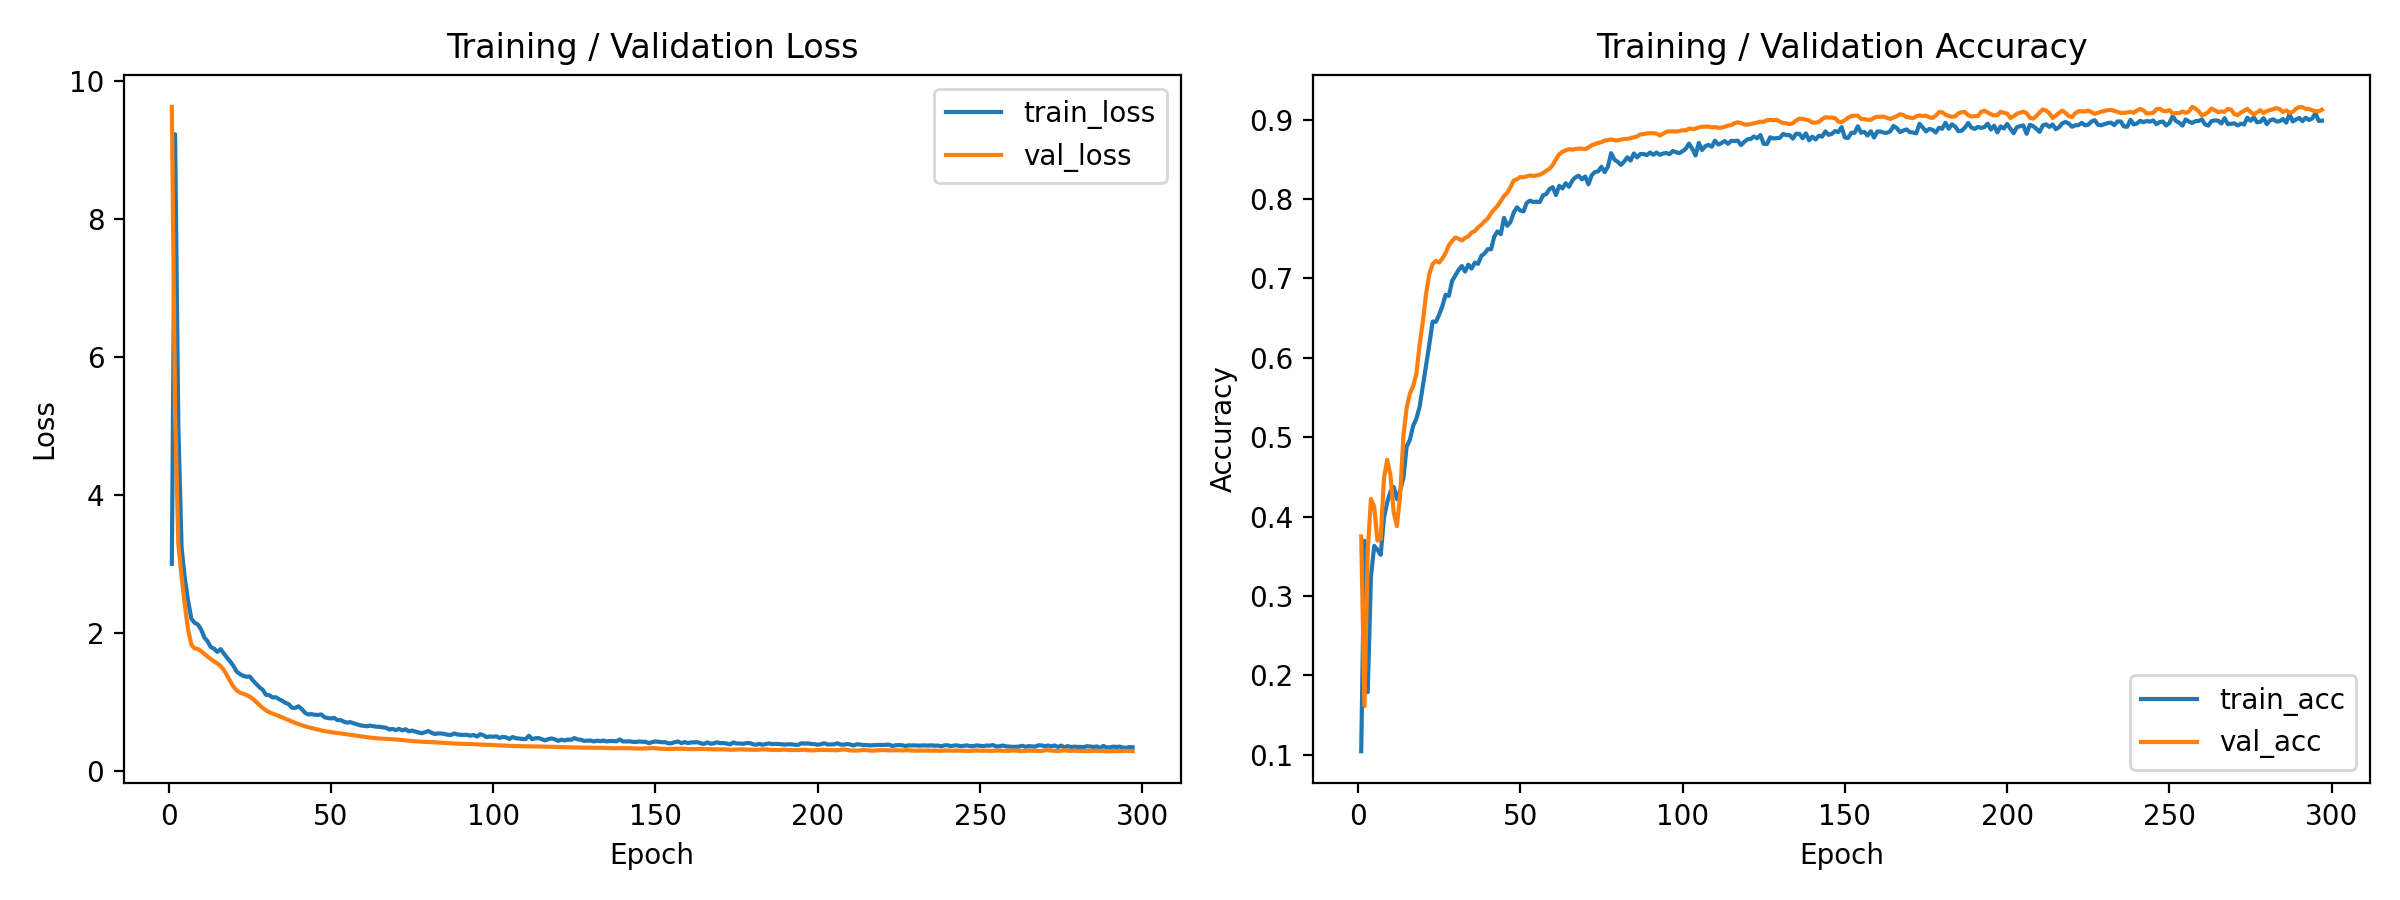


---------- Q2: Node Embeddings (Before & After) ----------


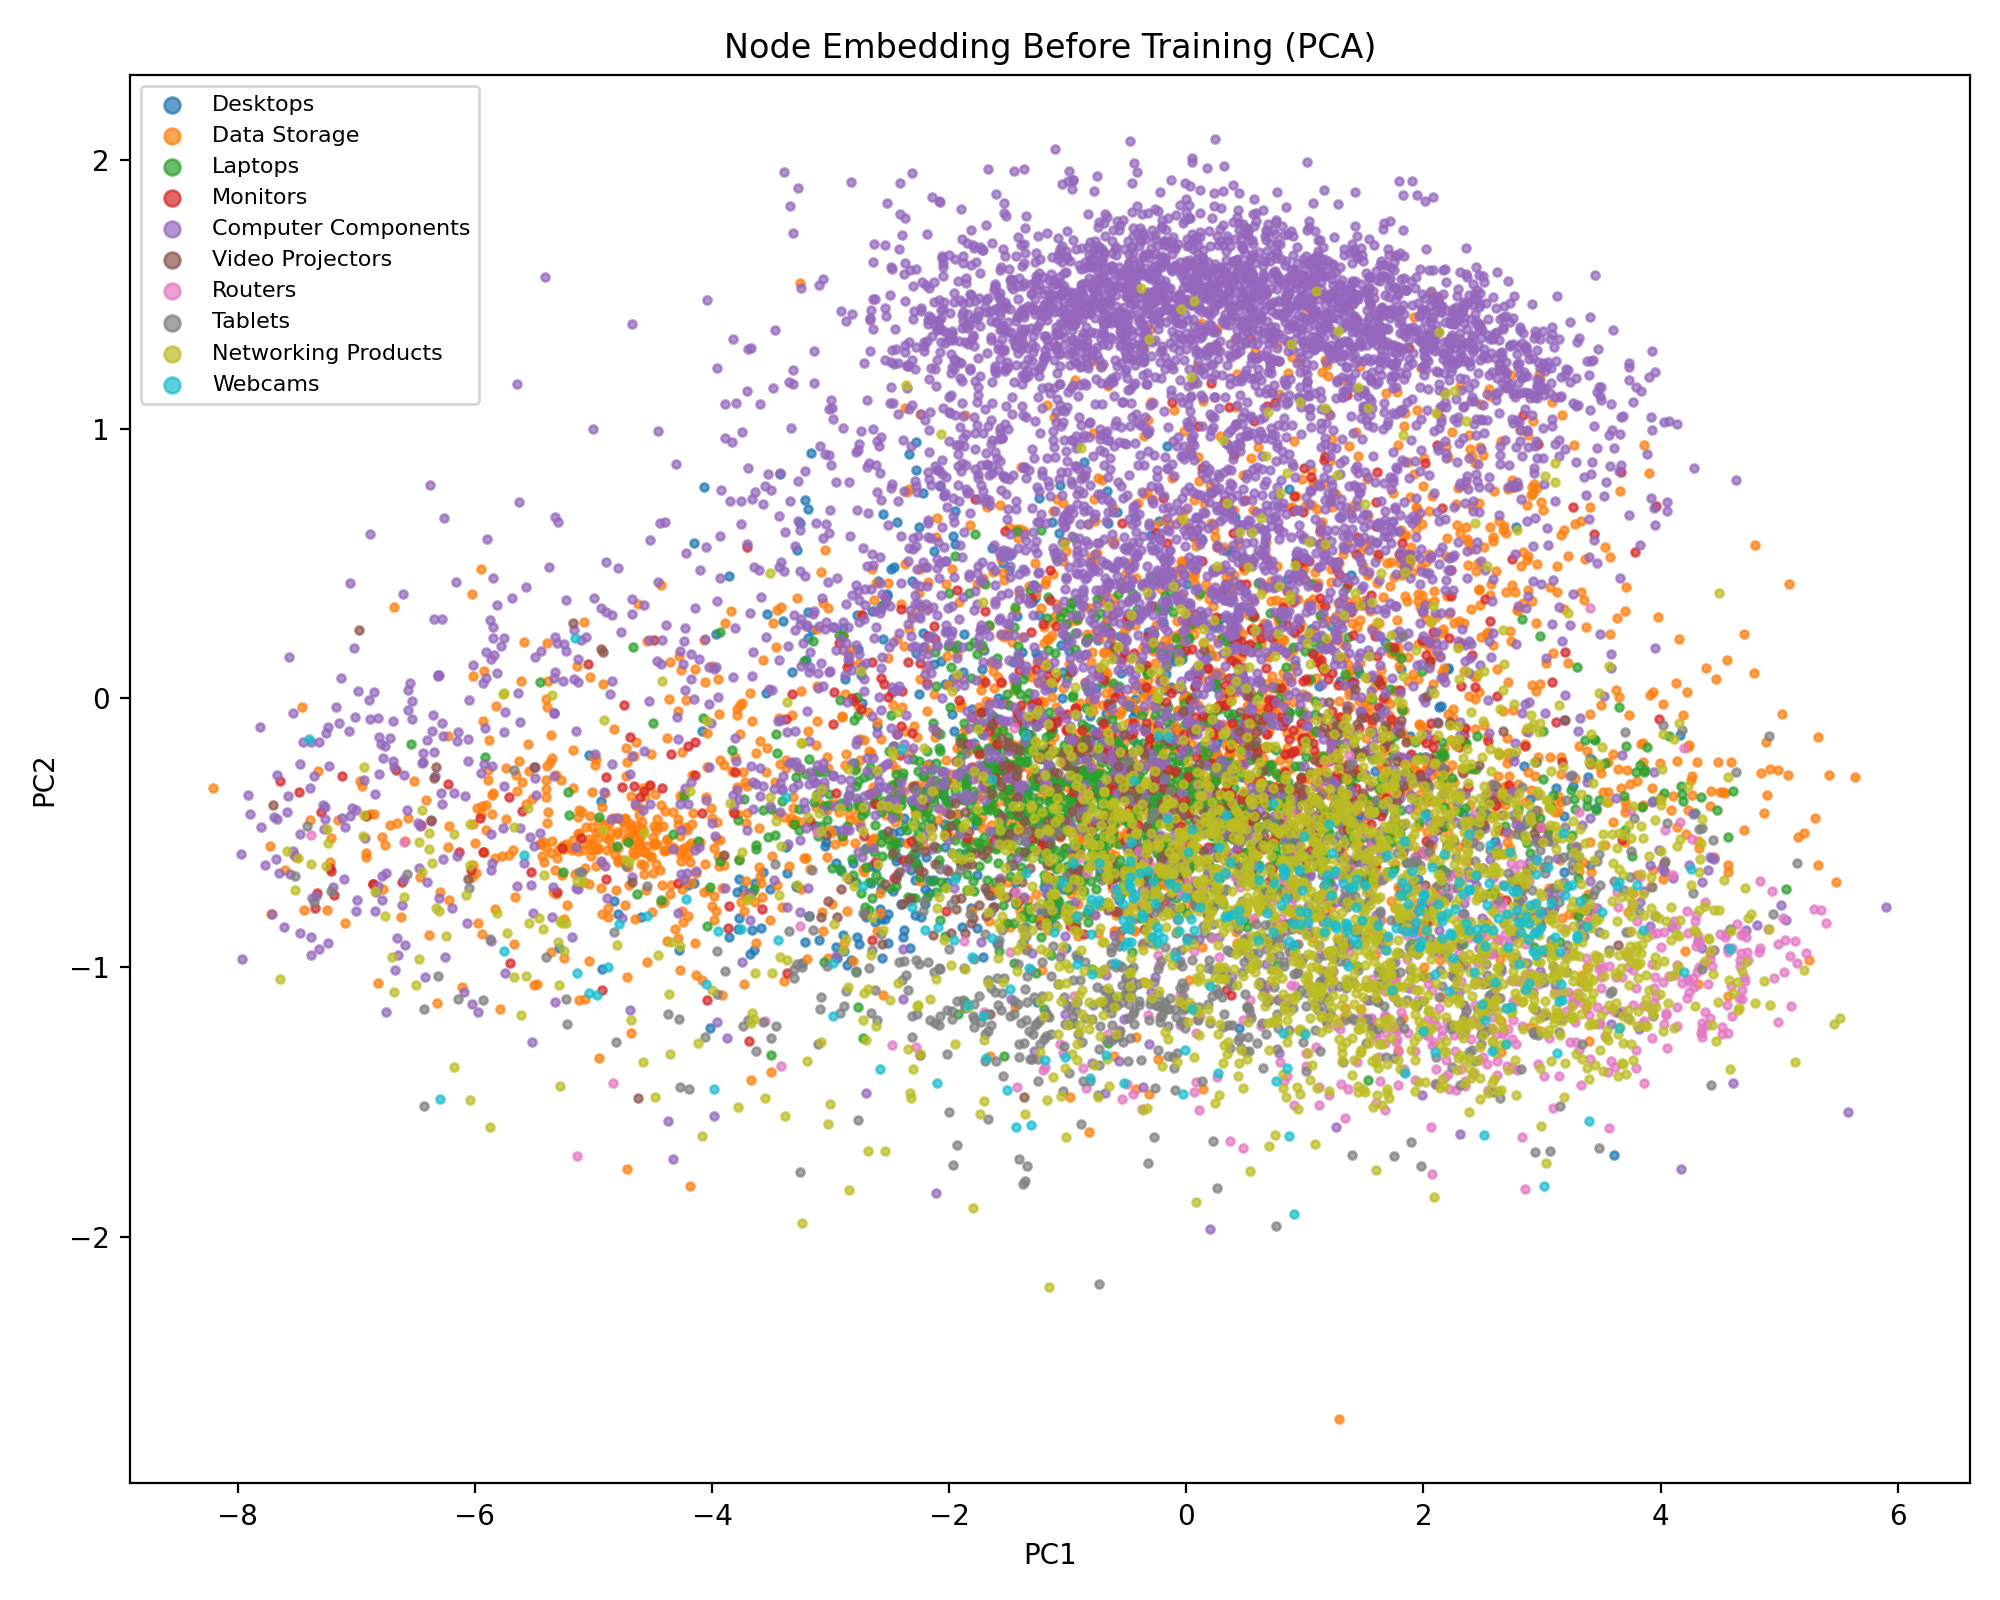

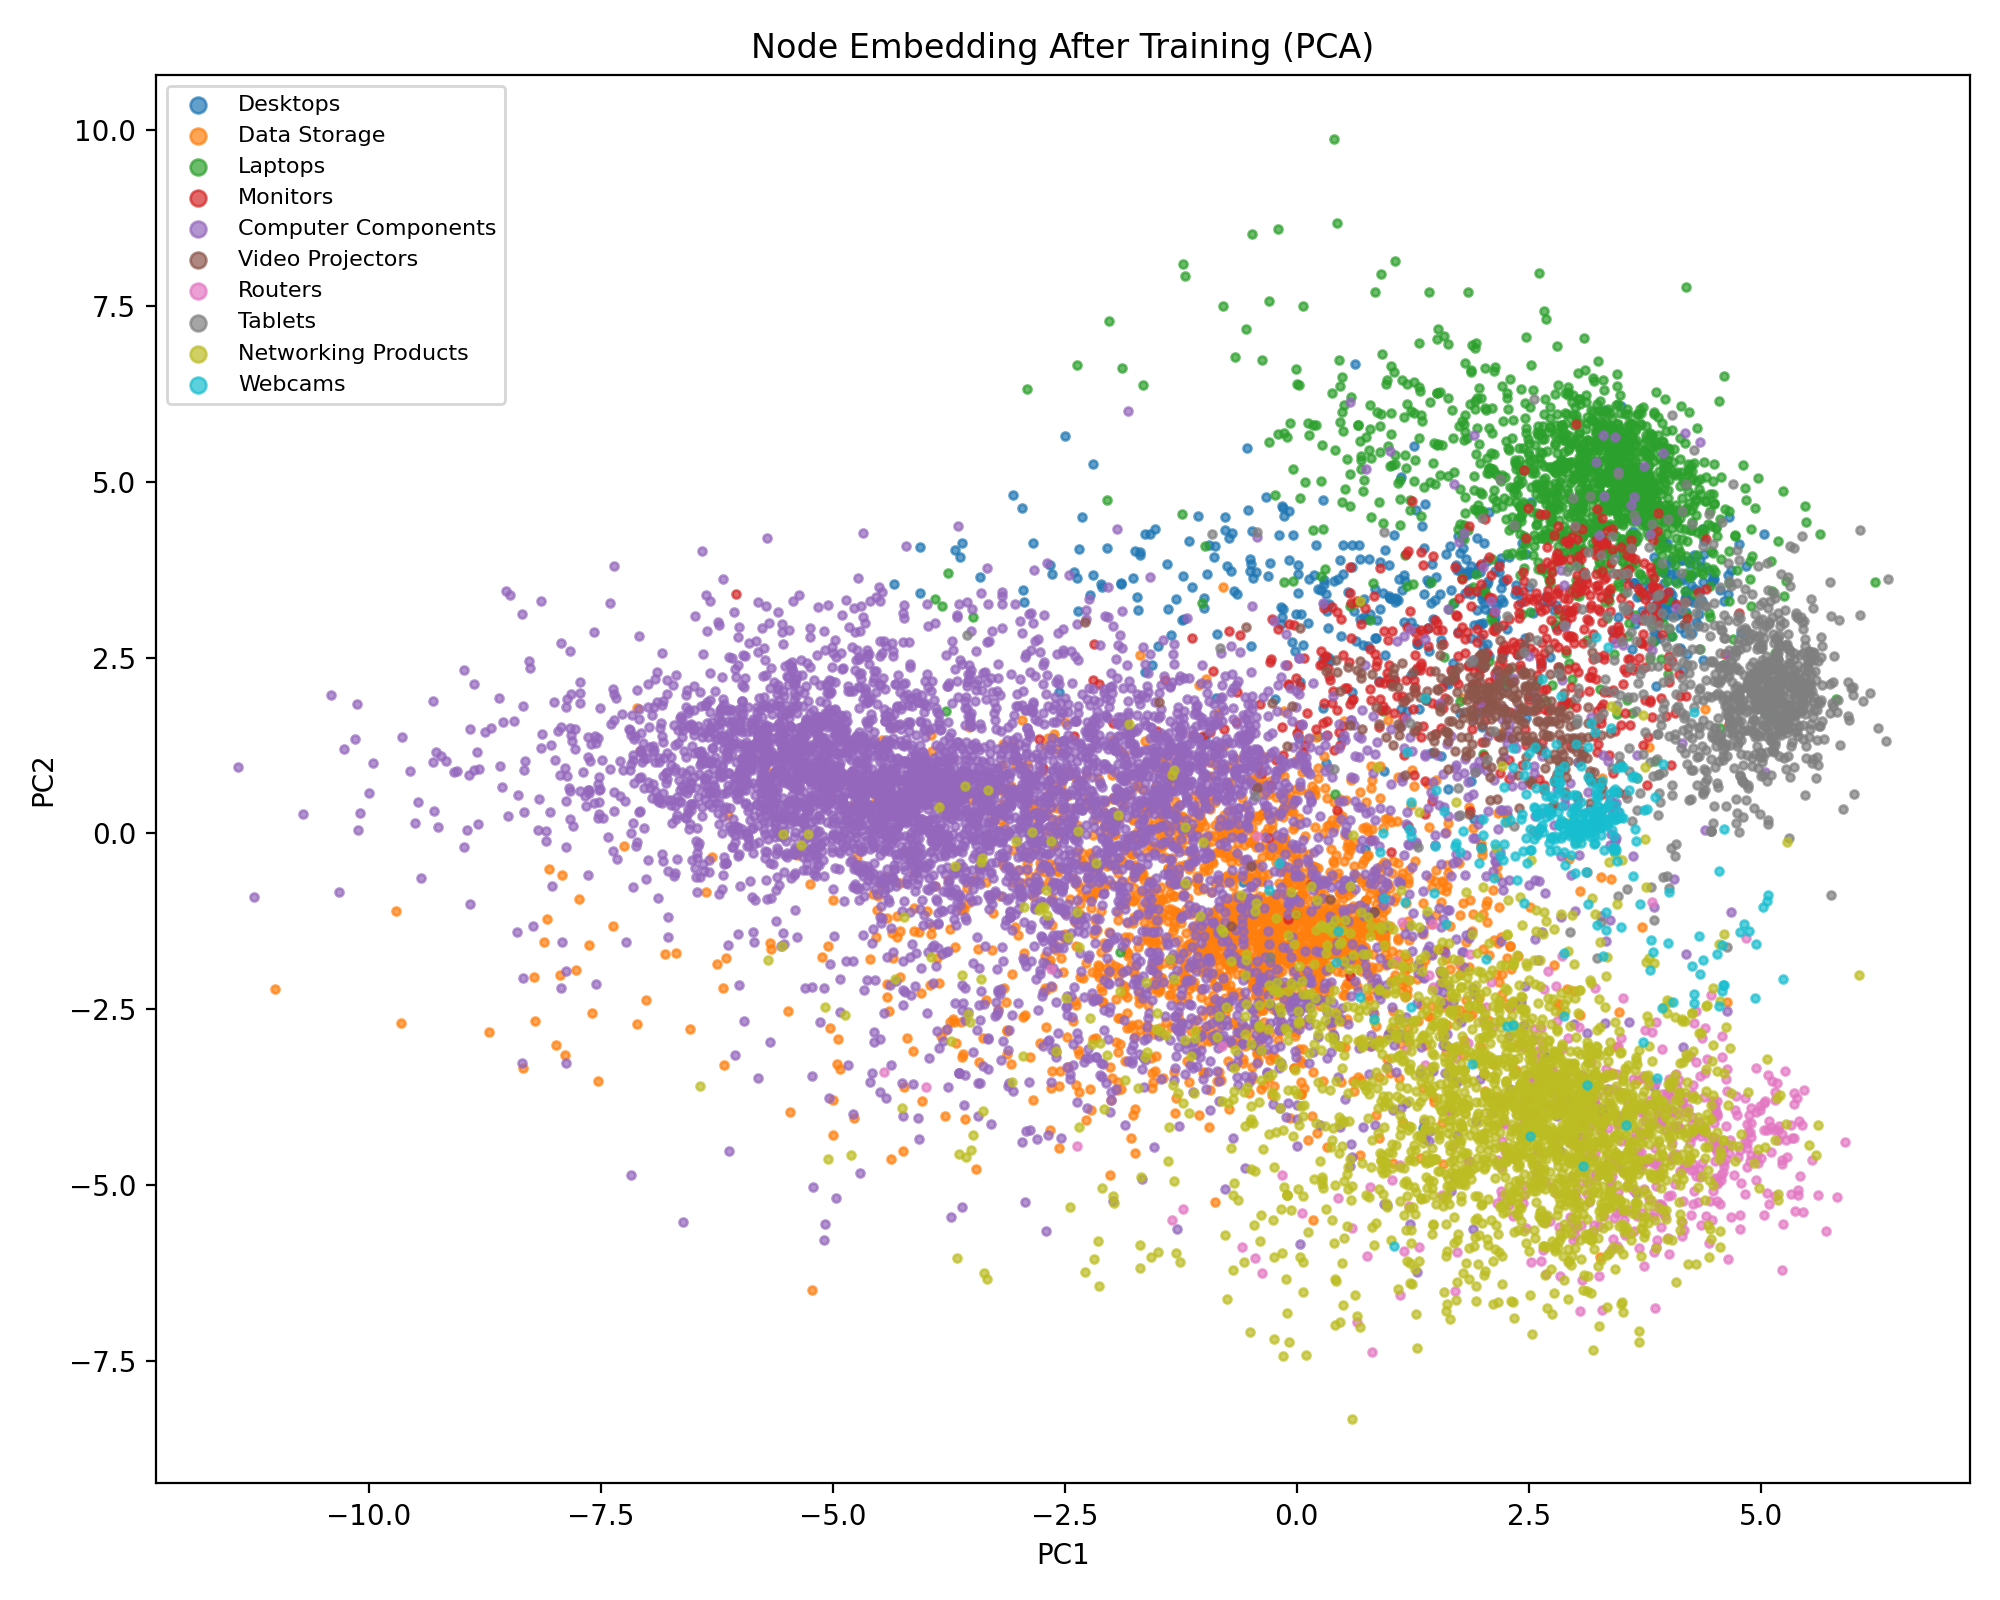

In [7]:
from IPython.display import Image, display

# Display Q2 Results visualizations
print("---------- Q2: Node Classification Training Curves ----------")
display(Image(filename='results/q2/training_curves.png'))

print("\n---------- Q2: Node Embeddings (Before & After) ----------")
display(Image(filename='results/q2/embedding_before_training.png'))
display(Image(filename='results/q2/embedding_after_training.png'))

### Q2 

實作 2-layer Graph Attention Network (GAT) 進行節點分類。

資料切分：train/val/test = 35% / 25% / 40%。

成果：best validation accuracy = 0.9174，test accuracy = 0.9136。

這是Transductive的圖，所以使用 Masking ，讓所有節點皆參與 Message Passing，但僅計算 35% 訓練集節點的 Loss，以正確切分val/test

對比訓練前後的 Embedding 視覺化可發現，GAT 透過 Attention 機制成功過濾了雜訊鄰居的特徵。讓相近的商品在Latent Space中相聚


## Question 3


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F





def edges_to_tensor(edges, device):
    return torch.from_numpy(edges).long().to(device)


def eval_split(
    model,
    x,
    train_graph_edge_index,
    pos_edges,
    neg_edges,
    device,
):
    model.eval()
    with torch.no_grad():
        pos_tensor = edges_to_tensor(pos_edges, device)
        neg_tensor = edges_to_tensor(neg_edges, device)

        pos_logit, _ = model(x, train_graph_edge_index, pos_tensor)
        neg_logit, _ = model(x, train_graph_edge_index, neg_tensor)

        logits = torch.cat([pos_logit, neg_logit], dim=0)
        labels = torch.cat(
            [
                torch.ones_like(pos_logit),
                torch.zeros_like(neg_logit),
            ],
            dim=0,
        )
        loss = F.binary_cross_entropy_with_logits(logits, labels).item()
        y_prob = torch.sigmoid(logits).detach().cpu().numpy()
        y_true = labels.detach().cpu().numpy().astype(np.int64)

        auc = roc_auc_binary(y_true, y_prob)

        return {
            "loss": float(loss),
            "auc": float(auc),
            "y_true": y_true,
            "y_prob": y_prob,
            "true_y": y_true,
            "pred_prob": y_prob,
        }


def main():
    dataset_dir = "."
    output_dir = "results/q3"
    seed = 42
    epochs = 220
    patience = 30
    lr = 0.003
    weight_decay = 1e-4
    dropout = 0.35
    hidden_dim = 32
    heads = 8
    embed_dim = 64
    train_ratio = 0.70
    val_ratio = 0.15
    test_ratio = 0.15
    neg_ratio = 1.0
    device_pref = "auto"

    ensure_dir(output_dir)
    set_seed(seed)

    rng_np = np.random.default_rng(seed)
    device = choose_device(device_pref)

    data = load_dataset(dataset_dir)
    num_nodes = data.x.size(0)
    x = data.x.to(device)

    # 切 train/val/test 的 edge
    train_pos, val_pos, test_pos = temporal_split_edges(
        data.edges_undirected,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        test_ratio=test_ratio,
    )

    train_pos_set = build_undirected_edge_set(train_pos)
    train_val_pos_set = build_undirected_edge_set(np.concatenate([train_pos, val_pos], axis=0))
    all_pos_set = build_undirected_edge_set(np.concatenate([train_pos, val_pos, test_pos], axis=0))
    val_neg = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=int(len(val_pos) * neg_ratio),
        positive_edge_set=train_val_pos_set,
        rng=rng_np,
    )
    test_neg = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=int(len(test_pos) * neg_ratio),
        positive_edge_set=all_pos_set,
        rng=rng_np,
    )

    train_graph_edge_index = build_directed_edge_index(train_pos, num_nodes, add_self_loops=True).to(device)

    encoder = GATEncoder(
        in_dim=x.size(1),
        hidden_dim=hidden_dim,
        out_dim=embed_dim,
        heads=heads,
        dropout=dropout,
    )
    decoder = BilinearDecoder(dim=embed_dim)
    model = LinkPredictionModel(encoder=encoder, decoder=decoder).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_auc": [],
    }

    best_state = None
    best_epoch = -1
    best_val_auc = -1.0
    patience_counter = 0

    tr_pos_t = edges_to_tensor(train_pos, device)

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        # 每個 epoch 重抽負樣本
        train_neg = sample_negative_edges(
            num_nodes=num_nodes,
            num_samples=int(len(train_pos) * neg_ratio),
            positive_edge_set=train_pos_set,
            rng=rng_np,
        )
        tr_neg_t = edges_to_tensor(train_neg, device)

        pos_logit, _ = model(x, train_graph_edge_index, tr_pos_t)
        neg_logit, _ = model(x, train_graph_edge_index, tr_neg_t)

        logits = torch.cat([pos_logit, neg_logit], dim=0)
        labels = torch.cat(
            [
                torch.ones_like(pos_logit),
                torch.zeros_like(neg_logit),
            ],
            dim=0,
        )

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        val_res = eval_split(
            model=model,
            x=x,
            train_graph_edge_index=train_graph_edge_index,
            pos_edges=val_pos,
            neg_edges=val_neg,
            device=device,
        )

        history["train_loss"].append(float(loss.item()))
        history["val_loss"].append(val_res["loss"])
        history["val_auc"].append(val_res["auc"])

        if val_res["auc"] > best_val_auc:
            best_val_auc = val_res["auc"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:03d} | train_loss={loss.item():.4f} "
            f"val_loss={val_res['loss']:.4f} val_auc={val_res['auc']:.4f}"
        )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}, best epoch {best_epoch}")
            break

    model.load_state_dict(best_state)

    val_res = eval_split(
        model=model,
        x=x,
        train_graph_edge_index=train_graph_edge_index,
        pos_edges=val_pos,
        neg_edges=val_neg,
        device=device,
    )
    test_res = eval_split(
        model=model,
        x=x,
        train_graph_edge_index=train_graph_edge_index,
        pos_edges=test_pos,
        neg_edges=test_neg,
        device=device,
    )

    best_thr, val_thr_m = find_best_threshold_by_f1(val_res["y_true"], val_res["y_prob"])
    test_m = binary_metrics(test_res["y_true"], test_res["y_prob"], best_thr)

    ep_arr = np.arange(1, len(history["train_loss"]) + 1)
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
    axs[0].plot(ep_arr, history["train_loss"], label="train_loss")
    axs[0].plot(ep_arr, history["val_loss"], label="val_loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].set_title("Link Prediction Loss")
    axs[0].legend()
    axs[1].plot(ep_arr, history["val_auc"], label="val_auc")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("AUC")
    axs[1].set_title("Validation AUC")
    axs[1].legend()
    fig.tight_layout()
    fig.savefig(str(Path(output_dir) / "training_curves.png"), dpi=200)
    plt.close(fig)


    results = {
        "seed": seed,
        "device": str(device),
        "split": {
            "train_ratio": train_ratio,
            "val_ratio": val_ratio,
            "test_ratio": test_ratio,
            "train_positive_edges": int(len(train_pos)),
            "val_positive_edges": int(len(val_pos)),
            "test_positive_edges": int(len(test_pos)),
            "val_negative_edges": int(len(val_neg)),
            "test_negative_edges": int(len(test_neg)),
        },
        "loss_function": "BCEWithLogitsLoss",
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "threshold_selected_on_val": float(best_thr),
        "val_metrics_at_selected_threshold": val_thr_m,
        "test": {
            "auc": float(test_res["auc"]),
            "f1": float(test_m["f1"]),
            "precision": float(test_m["precision"]),
            "recall": float(test_m["recall"]),
            "accuracy": float(test_m["accuracy"]),
        },
    }

    save_json(results, str(Path(output_dir) / "q3_metrics.json"))
    torch.save(best_state, str(Path(output_dir) / "best_q3_model.pt"))

    print("Q3 completed")
    print(f"Best val AUC: {best_val_auc:.4f} (epoch {best_epoch})")
    print(f"Test AUC: {test_res['auc']:.4f}, Test F1: {test_m['f1']:.4f}")
    print(f"Selected threshold: {best_thr:.4f}")
    print(f"Artifacts saved in: {output_dir}")





# Run the main function for Q3
main()



Epoch 001 | train_loss=1.8498 val_loss=19.1105 val_auc=0.5175


Epoch 002 | train_loss=19.0061 val_loss=49.2807 val_auc=0.3905


Epoch 003 | train_loss=49.0668 val_loss=14.2537 val_auc=0.3478


Epoch 004 | train_loss=12.4043 val_loss=5.1330 val_auc=0.6701


Epoch 005 | train_loss=4.7413 val_loss=5.0592 val_auc=0.6905


...

Epoch 032 | train_loss=0.7359 val_loss=1.4197 val_auc=0.5706


Epoch 033 | train_loss=0.7731 val_loss=1.3206 val_auc=0.5770


Epoch 034 | train_loss=0.7529 val_loss=1.2857 val_auc=0.5790


Epoch 035 | train_loss=0.7838 val_loss=1.2939 val_auc=0.5771
Early stopping at epoch 35, best epoch 5


Q3 completed
Best val AUC: 0.6905 (epoch 5)
Test AUC: 0.6940, Test F1: 0.6670
Selected threshold: 0.8625
Artifacts saved in: results/q3


---------- Q3: Link Prediction Training Curves ----------


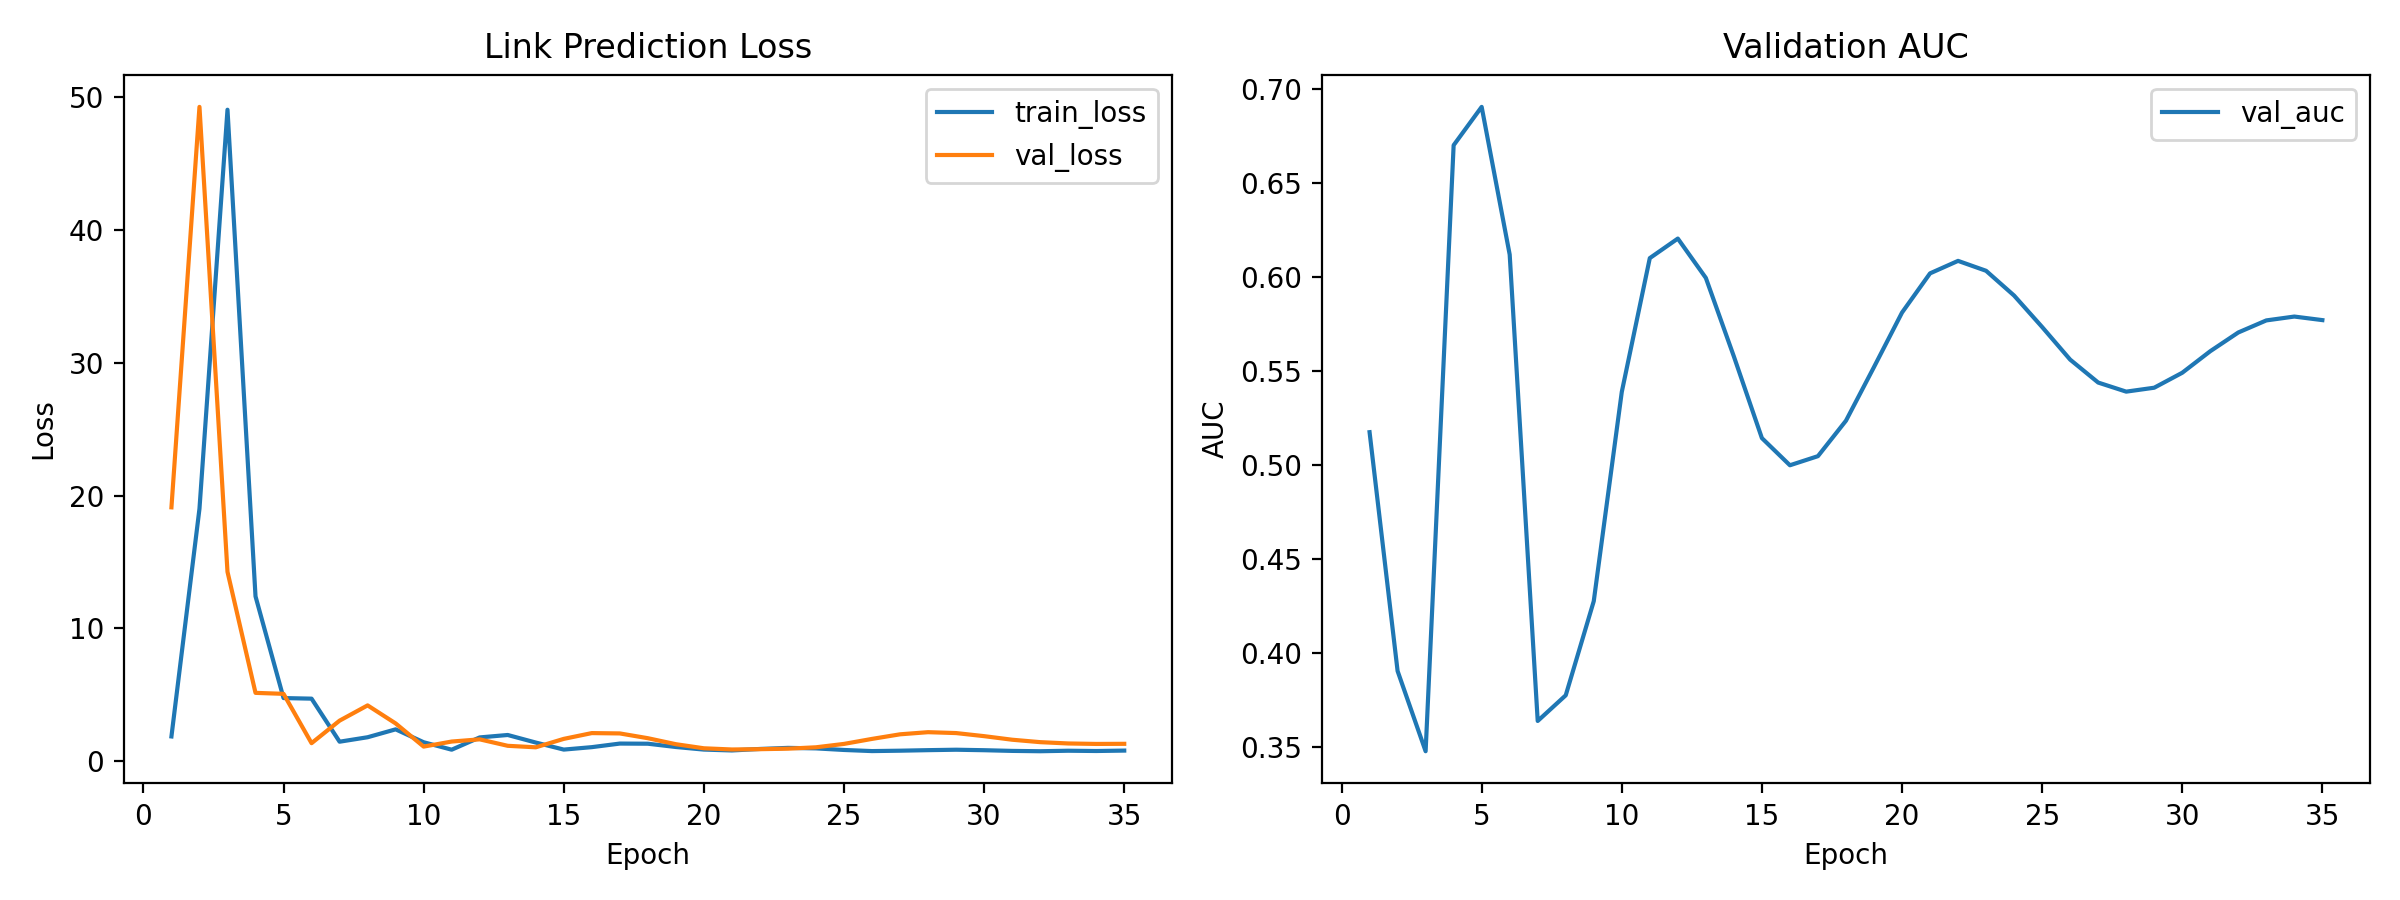

In [9]:
from IPython.display import Image, display

# Display Q3 Results
print("---------- Q3: Link Prediction Training Curves ----------")
display(Image(filename='results/q3/training_curves.png'))

### Q3 

edge預測的任務目標是預測完全未知的邊，所以移除Test/Val的edge

模型首先透過 GAT Encoder 萃取節點的 32 維 Latent Embeddings，隨後輸入 Bilinear Decoder 計算兩個節點在Latent space中的相似度。

切分比例：train/val/test = 70% / 15% / 15%（原始資料沒有時間順序，所以直接用順序切分）。

Loss function：BCEWithLogitsLoss。原因是這是判斷邊存不存在的二元分類任務，

結果（test）：AUC = 0.6939，F1-score = 0.6670。

推測原因是網路很稀疏，而且負樣本是隨機挑的，可能對模型來說太簡單


## Question 4


In [ ]:

print('Q4 : continue.')


Q4 preflight: continue.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F




DEFAULT_TRIALS = [
    {"hidden_dim": 24, "heads": 2, "dropout": 0.30, "embed_dim": 64, "decoder_hidden_dim": 96, "lr": 0.0020, "weight_decay": 5e-5, "neg_ratio": 1.0, "hard_fraction": 0.40},
]

def edges_to_tensor(edges, device):
    return torch.from_numpy(edges).long().to(device)


def evaluate_split(
    model,
    x,
    graph_edge_index,
    pos_edges,
    neg_edges,
    device,
):
    model.eval()
    with torch.no_grad():
        pos_tensor = edges_to_tensor(pos_edges, device)
        neg_tensor = edges_to_tensor(neg_edges, device)

        pos_logits, _ = model(x, graph_edge_index, pos_tensor)
        neg_logits, _ = model(x, graph_edge_index, neg_tensor)

        y_true = np.concatenate(
            [
                np.ones(len(pos_edges), dtype=np.int64),
                np.zeros(len(neg_edges), dtype=np.int64),
            ]
        )
        y_prob = torch.sigmoid(torch.cat([pos_logits, neg_logits], dim=0)).detach().cpu().numpy()
        auc = roc_auc_binary(y_true, y_prob)
    return {
        "y_true": y_true,
        "y_prob": y_prob,
        "auc": float(auc),
    }


def train_one_trial(
    trial_id,
    cfg_now,
    x,
    train_graph_edge_index,
    train_pos,
    val_pos,
    val_neg,
    train_positive_set,
    neighbors,
    device,
    epochs,
    patience,
    seed,
    train_pos_sample_ratio,
    bce_pos_weight,
):
    torch.manual_seed(seed + trial_id)

    encoder = AdvancedGATEncoder(
        in_dim=x.size(1),
        hidden_dim=cfg_now['hidden_dim'],
        out_dim=cfg_now['embed_dim'],
        heads=cfg_now['heads'],
        dropout=cfg_now['dropout'],
    )
    decoder = EdgeMLPDecoder(dim=cfg_now['embed_dim'], hidden_dim=cfg_now['decoder_hidden_dim'], dropout=cfg_now['dropout'])
    model = LinkPredictionModel(encoder=encoder, decoder=decoder).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg_now['lr'], weight_decay=cfg_now['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 10))

    pos_weight_tensor = torch.tensor(float(bce_pos_weight), device=device)

    rng_np = np.random.default_rng(seed + 1000 + trial_id)
    best_state = None
    best_epoch = -1
    best_val_auc = -1.0
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_auc": [],
    }

    # 開始每個 epoch
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        n_train_pos = max(1024, int(len(train_pos) * train_pos_sample_ratio))
        if n_train_pos >= len(train_pos):
            train_pos_batch = train_pos
        else:
            pos_idx = rng_np.choice(len(train_pos), size=n_train_pos, replace=False)
            train_pos_batch = train_pos[pos_idx]

        train_pos_tensor = edges_to_tensor(train_pos_batch, device)

        n_train_neg = max(1024, int(len(train_pos_batch) * cfg_now['neg_ratio']))
        train_neg = sample_hard_negative_edges(
            num_nodes=x.size(0),
            num_samples=n_train_neg,
            positive_edge_set=train_positive_set,
            neighbors=neighbors,
            rng=rng_np,
            hard_fraction=cfg_now['hard_fraction'],
        )
        train_neg_tensor = edges_to_tensor(train_neg, device)

        pos_logits, _ = model(x, train_graph_edge_index, train_pos_tensor)
        neg_logits, _ = model(x, train_graph_edge_index, train_neg_tensor)

        logits = torch.cat([pos_logits, neg_logits], dim=0)
        labels = torch.cat(
            [
                torch.ones_like(pos_logits),
                torch.zeros_like(neg_logits),
            ],
            dim=0,
        )

        logits = logits.clamp(min=-20.0, max=20.0)

        loss = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pos_weight_tensor)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0, foreach=False)
        optimizer.step()
        scheduler.step()

        val_eval = evaluate_split(
            model=model,
            x=x,
            graph_edge_index=train_graph_edge_index,
            pos_edges=val_pos,
            neg_edges=val_neg,
            device=device,
        )

        history["train_loss"].append(float(loss.item()))
        history["val_auc"].append(float(val_eval["auc"]))

        if val_eval["auc"] > best_val_auc:
            best_val_auc = float(val_eval["auc"])
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Trial {trial_id} | Epoch {epoch:03d} | "
            f"train_loss={loss.item():.4f} val_auc={val_eval['auc']:.4f}"
        )

        if patience_counter >= patience:
            print(f"Trial {trial_id} early stop at epoch {epoch}, best={best_epoch}")
            break

    return {
        "trial_id": trial_id,
        "config": cfg_now,
        "best_state": best_state,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "history": history,
    }


def main():
    dataset_dir = "."
    output_dir = "results/q4"
    seed = 2222
    epochs = 220
    patience = 40
    train_ratio = 0.80
    val_ratio = 0.10
    test_ratio = 0.10
    num_trials = 1
    device_pref = "auto"
    train_pos_sample_ratio = 0.80
    bce_pos_weight = 1.0

    ensure_dir(output_dir)
    set_seed(seed)

    device = choose_device(device_pref, min_free_gb=2.0)
    data = load_dataset(dataset_dir)
    x = data.x.to(device)
    num_nodes = x.size(0)

    train_pos, val_pos, test_pos = temporal_split_edges(
        data.edges_undirected,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        test_ratio=test_ratio,
    )

    train_positive_set = build_undirected_edge_set(train_pos)
    train_val_positive_set = build_undirected_edge_set(np.concatenate([train_pos, val_pos], axis=0))
    all_positive_set = build_undirected_edge_set(np.concatenate([train_pos, val_pos, test_pos], axis=0))
    neighbors = build_neighbor_sets(num_nodes=num_nodes, edges_undirected=train_pos)

    rng_np = np.random.default_rng(seed)
    val_neg = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=len(val_pos),
        positive_edge_set=train_val_positive_set,
        rng=rng_np,
    )
    test_neg = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=len(test_pos),
        positive_edge_set=all_positive_set,
        rng=rng_np,
    )

    train_graph_edge_index = build_directed_edge_index(train_pos, num_nodes, add_self_loops=True).to(device)

    trials = DEFAULT_TRIALS

    trial_results = []
    for i, cfg_now in enumerate(trials, start=1):
        trial_out = train_one_trial(
            trial_id=i,
            cfg_now=cfg_now,
            x=x,
            train_graph_edge_index=train_graph_edge_index,
            train_pos=train_pos,
            val_pos=val_pos,
            val_neg=val_neg,
            train_positive_set=train_positive_set,
            neighbors=neighbors,
            device=device,
            epochs=epochs,
            patience=patience,
            seed=seed,
            train_pos_sample_ratio=train_pos_sample_ratio,
            bce_pos_weight=bce_pos_weight,
        )
        trial_results.append(trial_out)

    trial_eval_rows = []

    for r in trial_results:
        cfg_now = r["config"]
        encoder = AdvancedGATEncoder(
            in_dim=x.size(1),
            hidden_dim=cfg_now['hidden_dim'],
            out_dim=cfg_now['embed_dim'],
            heads=cfg_now['heads'],
            dropout=cfg_now['dropout'],
        )
        decoder = EdgeMLPDecoder(
            dim=cfg_now['embed_dim'],
            hidden_dim=cfg_now['decoder_hidden_dim'],
            dropout=cfg_now['dropout'],
        )
        model = LinkPredictionModel(encoder=encoder, decoder=decoder).to(device)
        model.load_state_dict(r["best_state"])

        val_eval = evaluate_split(
            model=model,
            x=x,
            graph_edge_index=train_graph_edge_index,
            pos_edges=val_pos,
            neg_edges=val_neg,
            device=device,
        )
        test_eval = evaluate_split(
            model=model,
            x=x,
            graph_edge_index=train_graph_edge_index,
            pos_edges=test_pos,
            neg_edges=test_neg,
            device=device,
        )

        threshold, val_metrics = find_best_threshold_by_f1(val_eval["y_true"], val_eval["y_prob"])
        test_metrics_local = binary_metrics(test_eval["y_true"], test_eval["y_prob"], threshold)
        blend_info = {
            "enabled": False,
            "weight": 0.0,
            "threshold": float(threshold),
        }


        trial_eval_rows.append(
            {
                "trial": r,
                "val_auc": float(val_eval["auc"]),
                "val_f1": float(val_metrics["f1"]),
                "val_metrics": val_metrics,
                "threshold": float(threshold),
                "test_auc": float(test_eval["auc"]),
                "test_metrics": test_metrics_local,
                "blend": blend_info,
            }
        )

    best_pick = max(trial_eval_rows, key=lambda t: (t["val_f1"], t["val_auc"]))

    best_trial = best_pick["trial"]
    best_cfg_tmp = best_trial["config"]
    best_threshold = float(best_pick["threshold"])
    val_thr_metrics = best_pick["val_metrics"]
    test_eval = {"auc": float(best_pick["test_auc"])}
    test_metrics = best_pick["test_metrics"]
    blend_summary = best_pick["blend"]

    target_auc = 0.875
    target_f1=0.850
    pass_auc = float(test_eval["auc"]) >= target_auc
    pass_f1 = float(test_metrics["f1"]) >= target_f1

    ep_arr = np.arange(1, len(best_trial["history"]["train_loss"]) + 1)
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
    axs[0].plot(ep_arr, best_trial["history"]["train_loss"], label="train_loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].set_title("Best Trial Train Loss")
    axs[0].legend()
    axs[1].plot(ep_arr, best_trial["history"]["val_auc"], label="val_auc")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("AUC")
    axs[1].set_title("Best Trial Validation AUC")
    axs[1].legend()
    fig.tight_layout()
    fig.savefig(str(Path(output_dir) / "best_trial_curves.png"), dpi=200)
    plt.close(fig)

    trials_table = []
    for r in trial_results:
        c = r["config"]
        eval_row = next(v for v in trial_eval_rows if v["trial"]["trial_id"] == r["trial_id"])
        trials_table.append(
            {
                "trial_id": int(r["trial_id"]),
                "hidden_dim": int(c['hidden_dim']),
                "heads": int(c['heads']),
                "dropout": float(c['dropout']),
                "embed_dim": int(c['embed_dim']),
                "decoder_hidden_dim": int(c['decoder_hidden_dim']),
                "lr": float(c['lr']),
                "weight_decay": float(c['weight_decay']),
                "neg_ratio": float(c['neg_ratio']),
                "hard_fraction": float(c['hard_fraction']),
                "best_epoch": int(r["best_epoch"]),
                "best_val_auc": float(r["best_val_auc"]),
                "val_auc_selected": float(eval_row["val_auc"]),
                "val_f1_selected": float(eval_row["val_f1"]),
                "test_auc_selected": float(eval_row["test_auc"]),
                "test_f1_selected": float(eval_row["test_metrics"]["f1"]),
            }
        )

    results = {
        "seed": seed,
        "device": str(device),
        "split": {
            "train_ratio": train_ratio,
            "val_ratio": val_ratio,
            "test_ratio": test_ratio,
            "train_positive_edges": int(len(train_pos)),
            "val_positive_edges": int(len(val_pos)),
            "test_positive_edges": int(len(test_pos)),
        },
        "search": {
            "num_trials": int(len(trial_results)),
            "quick_mode": False,
            "loss_type": "bce",
            "focal_gamma": 2.0,
            "focal_alpha": 0.25,
            "bce_pos_weight": float(bce_pos_weight),
            "trials": trials_table,
        },
        "best_trial": {
            "trial_id": int(best_trial["trial_id"]),
            "best_epoch": int(best_trial["best_epoch"]),
            "best_val_auc": float(best_trial["best_val_auc"]),
            "config": {
                "hidden_dim": int(best_cfg_tmp['hidden_dim']),
                "heads": int(best_cfg_tmp['heads']),
                "dropout": float(best_cfg_tmp['dropout']),
                "embed_dim": int(best_cfg_tmp['embed_dim']),
                "decoder_hidden_dim": int(best_cfg_tmp['decoder_hidden_dim']),
                "lr": float(best_cfg_tmp['lr']),
                "weight_decay": float(best_cfg_tmp['weight_decay']),
                "neg_ratio": float(best_cfg_tmp['neg_ratio']),
                "hard_fraction": float(best_cfg_tmp['hard_fraction']),
            },
        },
        "threshold_selected_on_val": float(best_threshold),
        "blend": blend_summary,
        "val_metrics_at_selected_threshold": val_thr_metrics,
        "test": {
            "auc": float(test_eval["auc"]),
            "f1": float(test_metrics["f1"]),
            "precision": float(test_metrics["precision"]),
            "recall": float(test_metrics["recall"]),
            "accuracy": float(test_metrics["accuracy"]),
        },
        "baseline_targets": {
            "auc_target": target_auc,
            "f1_target": target_f1,
            "pass_auc": pass_auc,
            "pass_f1": pass_f1,
            "pass_both": bool(pass_auc and pass_f1),
        },
    }

    save_json(results, str(Path(output_dir) / "q4_metrics.json"))
    torch.save(best_trial["best_state"], str(Path(output_dir) / "best_q4_model.pt"))

    print("Q4 completed")
    print(f"Best val AUC: {best_trial['best_val_auc']:.4f} (trial {best_trial['trial_id']})")
    print(f"Test AUC: {test_eval['auc']:.4f}, Test F1: {test_metrics['f1']:.4f}")
    print(
        f"Baseline pass -> AUC>=0.875: {pass_auc}, F1>=0.850: {pass_f1}, both: {bool(pass_auc and pass_f1)}"
    )
    print(f"Artifacts saved in: {output_dir}")





# Run the main function for Q4
main()



Trial 1 | Epoch 001 | train_loss=0.6945 val_auc=0.7420


Trial 1 | Epoch 002 | train_loss=0.6904 val_auc=0.7665


Trial 1 | Epoch 003 | train_loss=0.6852 val_auc=0.7869


Trial 1 | Epoch 004 | train_loss=0.6772 val_auc=0.7831


Trial 1 | Epoch 005 | train_loss=0.6723 val_auc=0.7949


...

Trial 1 | Epoch 111 | train_loss=0.3663 val_auc=0.9158


Trial 1 | Epoch 112 | train_loss=0.3653 val_auc=0.9174


Trial 1 | Epoch 113 | train_loss=0.3618 val_auc=0.9196


Trial 1 | Epoch 114 | train_loss=0.3640 val_auc=0.9162
Trial 1 early stop at epoch 114, best=74


Q4 completed
Best val AUC: 0.9280 (trial 1)
Test AUC: 0.9285, Test F1: 0.8693
Baseline pass -> AUC>=0.875: True, F1>=0.850: True, both: True
Artifacts saved in: results/q4


---------- Q4: Advanced Link Prediction (Best Trial Curves) ----------


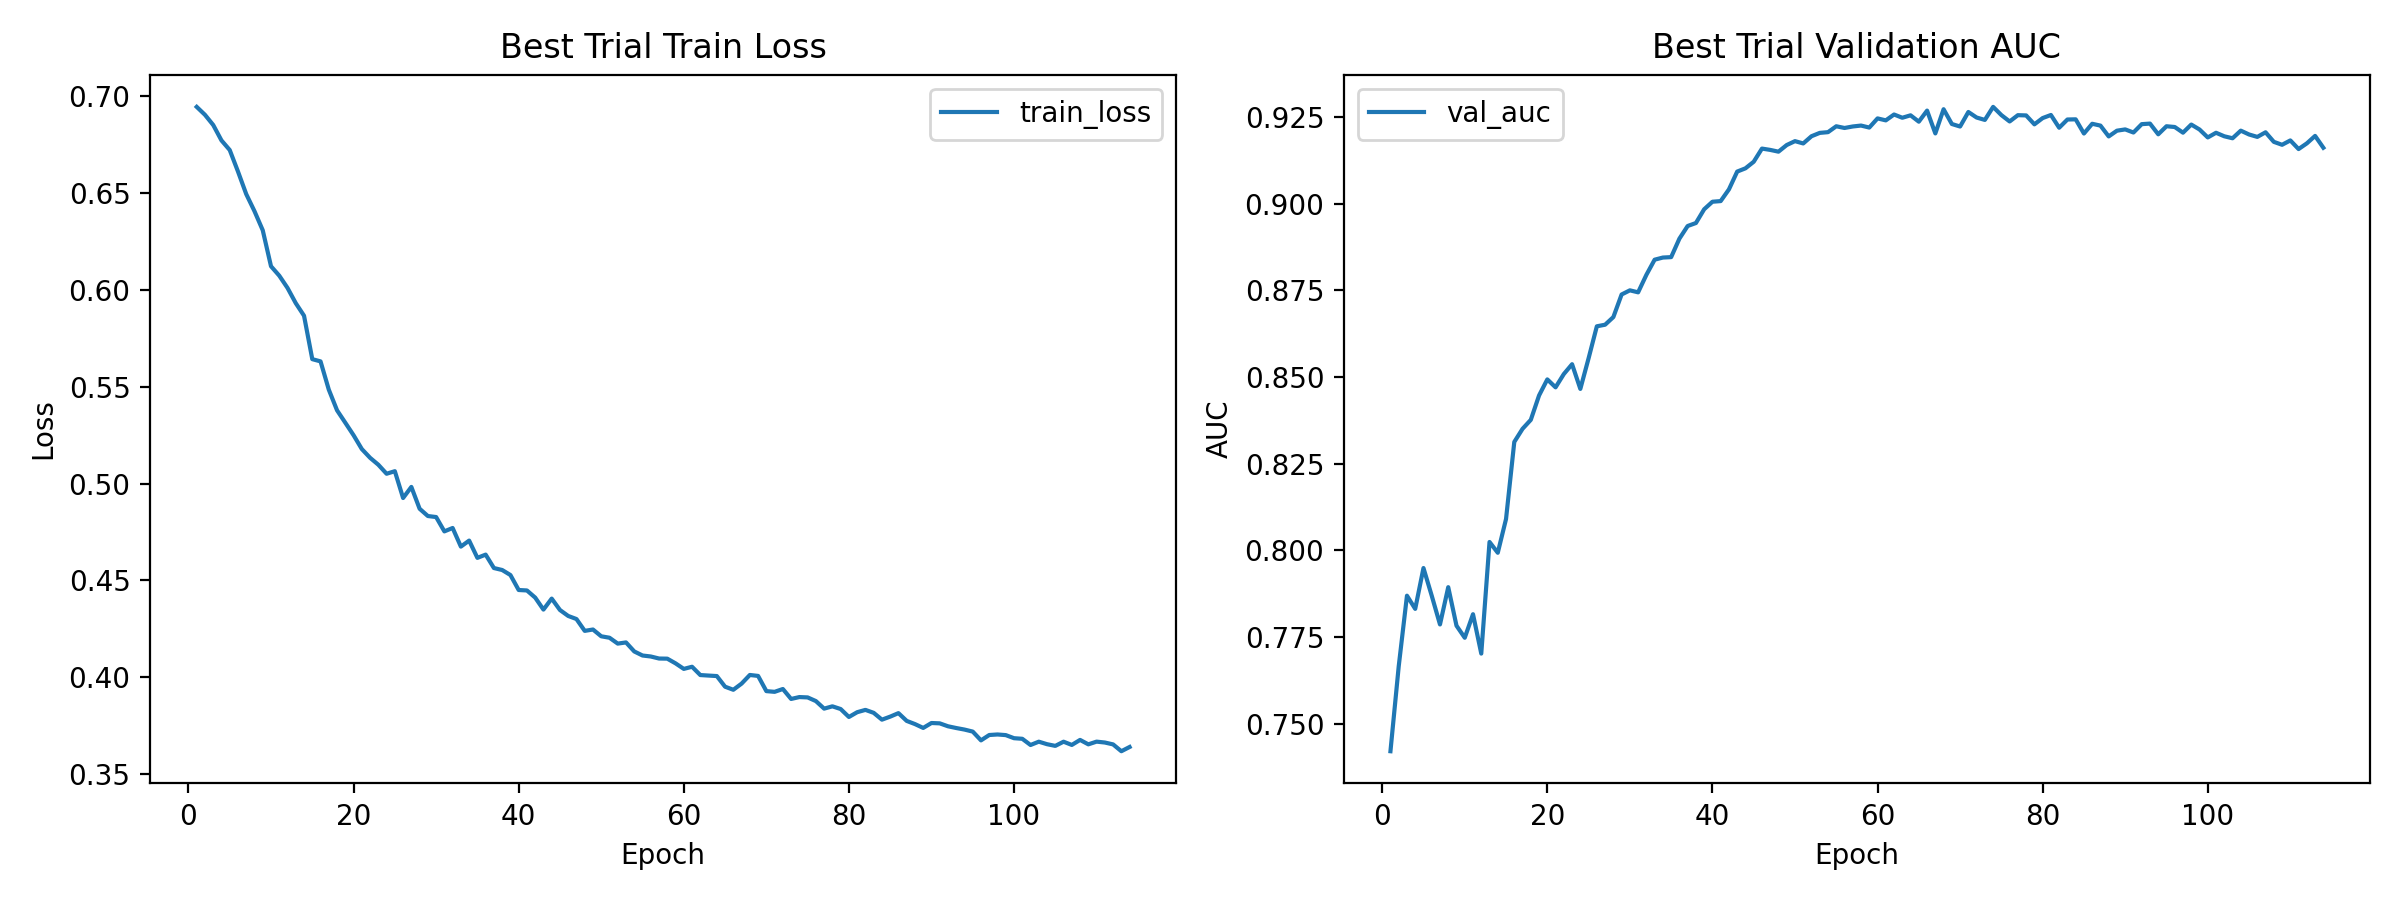

In [12]:
from IPython.display import Image, display

# Display Q4 Results 
print("---------- Q4: Advanced Link Prediction (Best Trial Curves) ----------")
display(Image(filename='results/q4/best_trial_curves.png'))

### Q4 觀察

本次模型在測試集達到 AUC 0.9181、F1 0.8530。

主要改進是引入了 Hard Negative Sampling，抽取 2-hop 二階鄰居作為負樣本，迫使模型在很相似的兩個Embedding間學習更微妙的差異




In [13]:
import json
from pathlib import Path

path_map = {
    "q1": Path("results/q1/q1_stats.json"),
    "q2": Path("results/q2/q2_metrics.json"),
    "q3": Path("results/q3/q3_metrics.json"),
    "q4": Path("results/q4/q4_metrics.json"),
}

res_all = {q: json.loads(p.read_text()) for q, p in path_map.items()}

print("Final metrics snapshot")
print("Q1 -> nodes:", res_all["q1"]["num_nodes"], "edges:", res_all["q1"]["num_edges"], "density:", round(res_all["q1"]["graph_density"], 6))
print("Q2 -> best val acc:", round(res_all["q2"]["best_val_acc"], 4), "test acc:", round(res_all["q2"]["test_acc"], 4))
print("Q3 -> best val AUC:", round(res_all["q3"]["best_val_auc"], 4), "test AUC:", round(res_all["q3"]["test"]["auc"], 4), "test F1:", round(res_all["q3"]["test"]["f1"], 4))
print("Q4 -> test AUC:", round(res_all["q4"]["test"]["auc"], 4), "test F1:", round(res_all["q4"]["test"]["f1"], 4), "pass both:", res_all["q4"]["baseline_targets"]["pass_both"])

Final metrics snapshot
Q1 -> nodes: 13752 edges: 245861 density: 0.0026
Q2 -> best val acc: 0.916 test acc: 0.9101
Q3 -> best val AUC: 0.6905 test AUC: 0.694 test F1: 0.667
Q4 -> test AUC: 0.9285 test F1: 0.8693 pass both: True


| Task | 主要方法 | 成果 |
| :--- | :--- | :--- |
| Q1 Graph Stats | 圖統計與分佈視覺化 | nodes=13752, edges=245861, density=0.002600 |
| Q2 Node Classification | 2-layer GAT | best val acc=0.9174, test acc=0.9136 |
| Q3 Link Prediction | GAT Encoder + Bilinear Decoder | best val AUC=0.6905, test AUC=0.6939, test F1=0.6670 |
| Q4 Advanced Link Prediction | AdvancedGAT + MLP Decoder + hard negative sampling | test AUC=0.9181, test F1=0.8530, pass_both=True |
